# Proiect AAD - Checkpoint 1 + Checkpoint 2
## Relația dintre cafeină, energie, somn și puls

## Componența echipei
- Roibu Radu Gheorghe - 343C3
- Ionescu Corina Ana
- Lazar Alessia-Alessandra

## Context, motivație și întrebare centrală
Folosim date reale NHANES pentru a urmări, la nivel de participant, cum se leagă consumul de cafeină de aportul energetic, somn, puls și câteva caracteristici demografice. Tema este relevantă tocmai pentru că discută un comportament foarte comun, dar îl tratează cu prudență statistică, nu cu presupuneri intuitive.

Întrebarea centrală a notebook-ului este: **în ce măsură apar, în aceste date observaționale, asocieri plauzibile între cafeină, odihnă și puls?** Ne interesează atât semnalele care apar, cât și absența unor relații puternice.

## Obiectiv și ipoteză de lucru
Obiectivul este să construim un lot final coerent din patru surse NHANES, să îl curățăm responsabil, să descriem relațiile principale prin analiză exploratorie și apoi să verificăm, prin modelare, cât semnal predictiv rămâne în date.

Ipoteza de pornire este moderată: un aport mai mare de cafeină s-ar putea asocia cu un puls ușor mai ridicat și cu mai puține ore de somn. Notebook-ul nu urmărește să demonstreze cauzalitate, ci să ofere o analiză exploratorie și educațională, prezentată clar și onest.


## Etapa 1: Alegerea surselor și pregătirea cadrului de lucru

Prima parte stabilește baza întregului proiect: alegem sursele NHANES relevante, verificăm ce aduce fiecare și pregătim un set de coloane care poate susține aceeași poveste analitică de la început până la final.

Lucrăm exclusiv cu tabele la nivel de participant și folosim `SEQN` drept cheie comună. Această alegere ne permite să trecem firesc de la date brute la lotul final, iar apoi la EDA și modelare, fără să schimbăm logica proiectului pe parcurs.

### Sursele folosite
- `caffeine_energy.csv`
- `pulse_bp.csv`
- `sleep.csv`
- `demographics.csv`

### Ce obținem la finalul etapei
O imagine clară asupra celor patru tabele și un set de variabile selectate special pentru întrebarea noastră de cercetare: relația dintre cafeină, energie, somn și puls în rândul adulților.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 115,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlepad": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
})

caffeine_palette = {
    "Low": "#8ecae6",
    "Moderate": "#219ebc",
    "High": "#fb8500",
    "Very High": "#d62828",
}
gender_palette = {
    "Female": "#e76f51",
    "Male": "#457b9d",
    "Unknown": "#94d2bd",
}
radar_palette = {
    "Low": "#457b9d",
    "Moderate": "#2a9d8f",
    "High": "#f4a261",
    "Very High": "#d62828",
}
variable_labels = {
    "caffeine_mg": "Cafeină (mg)",
    "energy_kcal": "Energie (kcal)",
    "pulse": "Puls (bătăi/minut)",
    "avg_sleep_hours": "Somn mediu ponderat (ore)",
    "age": "Vârstă (ani)",
    "avg_systolic_bp": "TA sistolică medie",
    "avg_diastolic_bp": "TA diastolică medie",
}


### 1.1 Încărcarea și înțelegerea celor patru tabele

Începem prin a încărca cele patru fișiere principale și prin a le rezuma într-o formă compactă. Nu ne interesează să parcurgem toate coloanele brute, ci să înțelegem rapid ce tip de informație aduce fiecare sursă și cum contribuie ea la întrebarea proiectului.

În practică, cele patru tabele acoperă patru dimensiuni complementare: nutriție, semne vitale, somn și demografie. Această împărțire este utilă și pentru prezentare, deoarece explică din start de ce avem nevoie de mai mult de un singur fișier.


In [2]:
data_dir = Path(".")

main_file_map = {
    "caffeine_energy": "caffeine_energy.csv",
    "pulse_bp": "pulse_bp.csv",
    "sleep": "sleep.csv",
    "demographics": "demographics.csv",
}

missing_files = [csv_name for csv_name in main_file_map.values() if not (data_dir / csv_name).exists()]
if missing_files:
    raise FileNotFoundError("Lipsesc fisierele CSV: " + ", ".join(missing_files))

datasets = {}

for dataset_name, csv_name in main_file_map.items():
    csv_path = data_dir / csv_name
    df = pd.read_csv(csv_path)
    datasets[dataset_name] = df
    print(f"[OK] {csv_path.name} a fost incarcat. Shape: {df.shape}")

caffeine_energy_df = datasets["caffeine_energy"]
pulse_bp_df = datasets["pulse_bp"]
sleep_df = datasets["sleep"]
demographics_df = datasets["demographics"]


[OK] caffeine_energy.csv a fost incarcat. Shape: (8704, 168)
[OK] pulse_bp.csv a fost incarcat. Shape: (8704, 21)
[OK] sleep.csv a fost incarcat. Shape: (6161, 11)
[OK] demographics.csv a fost incarcat. Shape: (9254, 46)


In [3]:
dataset_context = {
    "caffeine_energy": {
        "nivel": "participant",
        "ce_adaugă": "aport energetic total și cafeină pentru ziua de referință",
    },
    "pulse_bp": {
        "nivel": "participant",
        "ce_adaugă": "puls și măsurători repetate de tensiune arterială",
    },
    "sleep": {
        "nivel": "participant",
        "ce_adaugă": "ore de somn în zile lucrătoare și în weekend",
    },
    "demographics": {
        "nivel": "participant",
        "ce_adaugă": "vârstă și gen pentru filtrare și contextualizare",
    },
}

raw_summary = pd.DataFrame([
    {
        "dataset": dataset_name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "nivel": dataset_context[dataset_name]["nivel"],
        "ce_adaugă": dataset_context[dataset_name]["ce_adaugă"],
        "cheie_join": "SEQN",
        "exemplu_coloane_brute": ", ".join(df.columns[:6]) + (" ..." if df.shape[1] > 6 else ""),
    }
    for dataset_name, df in datasets.items()
])

display(raw_summary)


,dataset,rows,columns,nivel,ce_adaugă,cheie_join,exemplu_coloane_brute
0,caffeine_energy,8704,168,participant,aport energetic total și cafeină pentru ziua d...,SEQN,"SEQN, WTDRD1, WTDR2D, DR1DRSTZ, DR1EXMER, DRAB..."
1,pulse_bp,8704,21,participant,puls și măsurători repetate de tensiune arterială,SEQN,"SEQN, PEASCCT1, BPXCHR, BPAARM, BPACSZ, BPXPLS..."
2,sleep,6161,11,participant,ore de somn în zile lucrătoare și în weekend,SEQN,"SEQN, SLQ300, SLQ310, SLD012, SLQ320, SLQ330 ..."
3,demographics,9254,46,participant,vârstă și gen pentru filtrare și contextualizare,SEQN,"SEQN, SDDSRVYR, RIDSTATR, RIAGENDR, RIDAGEYR, ..."


#### Selectarea coloanelor relevante și redenumirea lor

Fișierele NHANES conțin multe coloane tehnice sau periferice față de obiectivul curent. În acest notebook păstrăm doar variabilele necesare pentru construirea lotului final și pentru interpretarea relațiilor dintre cafeină, energie, somn și puls.

Logica selecției este simplă:
- păstrăm variabilele direct legate de întrebarea de cercetare;
- păstrăm identificatorul `SEQN`, fără de care nu putem uni tabelele;
- păstrăm măsurătorile repetate de tensiune pentru a putea construi ulterior rezumate mai stabile;
- renunțăm la coloanele care nu aduc informație nouă pentru obiectivul actual, ca să evităm încărcarea inutilă a notebook-ului.


In [4]:
def select_and_rename_columns(df, rename_map, dataset_name, required_columns=None):
    if required_columns is None:
        required_columns = list(rename_map.keys())

    missing_required = [col for col in required_columns if col not in df.columns]
    if missing_required:
        raise KeyError(f"In tabelul {dataset_name} lipsesc coloanele: {missing_required}")

    selected_df = df[list(rename_map.keys())].copy()
    selected_df = selected_df.rename(columns=rename_map)
    return selected_df


nutrition_rename_map = {
    "SEQN": "SEQN",
    "DR1TKCAL": "energy_kcal",
    "DR1TCAFF": "caffeine_mg",
}

bp_rename_map = {
    "SEQN": "SEQN",
    "BPXPLS": "pulse",
    "BPXSY1": "systolic_1",
    "BPXDI1": "diastolic_1",
    "BPXSY2": "systolic_2",
    "BPXDI2": "diastolic_2",
    "BPXSY3": "systolic_3",
    "BPXDI3": "diastolic_3",
    "BPXSY4": "systolic_4",
    "BPXDI4": "diastolic_4",
}

sleep_rename_map = {
    "SEQN": "SEQN",
    "SLD012": "sleep_weekday_hours",
    "SLD013": "sleep_weekend_hours",
}

demographics_rename_map = {
    "SEQN": "SEQN",
    "RIDAGEYR": "age",
    "RIAGENDR": "gender_code",
}

nutrition_selected = select_and_rename_columns(caffeine_energy_df, nutrition_rename_map, "caffeine_energy.csv")
bp_selected = select_and_rename_columns(pulse_bp_df, bp_rename_map, "pulse_bp.csv", required_columns=["SEQN", "BPXPLS"])
sleep_selected = select_and_rename_columns(sleep_df, sleep_rename_map, "sleep.csv")
demographics_selected = select_and_rename_columns(demographics_df, demographics_rename_map, "demographics.csv")

demographics_selected["gender"] = demographics_selected["gender_code"].map({1: "Male", 2: "Female"})


In [5]:
data_dictionary = pd.DataFrame([
    {
        "fișier": "caffeine_energy.csv",
        "coloană_inițială": "DR1TKCAL",
        "coloană_finală": "energy_kcal",
        "rol_în_analiză": "aport energetic zilnic",
        "de_ce_o_păstrăm": "contextualizează consumul și poate explica parțial variația cafeinei și a pulsului",
    },
    {
        "fișier": "caffeine_energy.csv",
        "coloană_inițială": "DR1TCAFF",
        "coloană_finală": "caffeine_mg",
        "rol_în_analiză": "variabila centrală de interes",
        "de_ce_o_păstrăm": "măsoară direct aportul de cafeină pe care îl investigăm",
    },
    {
        "fișier": "pulse_bp.csv",
        "coloană_inițială": "BPXPLS",
        "coloană_finală": "pulse",
        "rol_în_analiză": "țintă descriptivă și țintă de regresie",
        "de_ce_o_păstrăm": "este principalul indicator fiziologic urmărit în proiect",
    },
    {
        "fișier": "pulse_bp.csv",
        "coloană_inițială": "BPXSY1 ... BPXSY4",
        "coloană_finală": "systolic_*",
        "rol_în_analiză": "măsurători repetate de TA sistolică",
        "de_ce_o_păstrăm": "permit construirea unei medii mai stabile decât o singură citire",
    },
    {
        "fișier": "pulse_bp.csv",
        "coloană_inițială": "BPXDI1 ... BPXDI4",
        "coloană_finală": "diastolic_*",
        "rol_în_analiză": "măsurători repetate de TA diastolică",
        "de_ce_o_păstrăm": "completează profilul cardiovascular și ajută la comparații",
    },
    {
        "fișier": "sleep.csv",
        "coloană_inițială": "SLD012",
        "coloană_finală": "sleep_weekday_hours",
        "rol_în_analiză": "somn în zile lucrătoare",
        "de_ce_o_păstrăm": "intră direct în media săptămânală ponderată a somnului",
    },
    {
        "fișier": "sleep.csv",
        "coloană_inițială": "SLD013",
        "coloană_finală": "sleep_weekend_hours",
        "rol_în_analiză": "somn în weekend",
        "de_ce_o_păstrăm": "completează componenta de odihnă și reduce riscul unei măsuri incomplete",
    },
    {
        "fișier": "demographics.csv",
        "coloană_inițială": "RIDAGEYR",
        "coloană_finală": "age",
        "rol_în_analiză": "filtrare și covariabilă explicativă",
        "de_ce_o_păstrăm": "permite restricția la adulți și explică diferențe fiziologice importante",
    },
    {
        "fișier": "demographics.csv",
        "coloană_inițială": "RIAGENDR",
        "coloană_finală": "gender",
        "rol_în_analiză": "covariabilă categorică",
        "de_ce_o_păstrăm": "oferă context descriptiv și este folosită în modelare",
    },
])

display(data_dictionary)


,fișier,coloană_inițială,coloană_finală,rol_în_analiză,de_ce_o_păstrăm
0,caffeine_energy.csv,DR1TKCAL,energy_kcal,aport energetic zilnic,contextualizează consumul și poate explica par...
1,caffeine_energy.csv,DR1TCAFF,caffeine_mg,variabila centrală de interes,măsoară direct aportul de cafeină pe care îl i...
2,pulse_bp.csv,BPXPLS,pulse,țintă descriptivă și țintă de regresie,este principalul indicator fiziologic urmărit ...
3,pulse_bp.csv,BPXSY1 ... BPXSY4,systolic_*,măsurători repetate de TA sistolică,permit construirea unei medii mai stabile decâ...
4,pulse_bp.csv,BPXDI1 ... BPXDI4,diastolic_*,măsurători repetate de TA diastolică,completează profilul cardiovascular și ajută l...
5,sleep.csv,SLD012,sleep_weekday_hours,somn în zile lucrătoare,intră direct în media săptămânală ponderată a ...
6,sleep.csv,SLD013,sleep_weekend_hours,somn în weekend,completează componenta de odihnă și reduce ris...
7,demographics.csv,RIDAGEYR,age,filtrare și covariabilă explicativă,permite restricția la adulți și explică difere...
8,demographics.csv,RIAGENDR,gender,covariabilă categorică,oferă context descriptiv și este folosită în m...


In [6]:
readable_previews = {
    "Nutritie - cafeina si energie": nutrition_selected,
    "Semne vitale - puls si tensiune": bp_selected,
    "Somn": sleep_selected,
    "Demografie": demographics_selected[["SEQN", "age", "gender_code", "gender"]],
}

for table_name, df in readable_previews.items():
    print("=" * 90)
    print(table_name)
    display(df.head())


Nutritie - cafeina si energie


,SEQN,energy_kcal,caffeine_mg
0,93703,NaN,NaN
1,93704,"1,230.00",8.00
2,93705,"1,202.00",361.00
3,93706,"1,987.00",0.00
4,93707,"1,775.00",21.00


Semne vitale - puls si tensiune


,SEQN,pulse,systolic_1,diastolic_1,systolic_2,diastolic_2,systolic_3,diastolic_3,systolic_4,diastolic_4
0,93703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705,52.00,NaN,NaN,NaN,NaN,202.00,62.00,198.00,74.00
3,93706,82.00,112.00,74.00,114.00,70.00,108.00,76.00,NaN,NaN
4,93707,100.00,128.00,38.00,128.00,46.00,128.00,58.00,NaN,NaN


Somn


,SEQN,sleep_weekday_hours,sleep_weekend_hours
0,93705,8.00,8.00
1,93706,10.50,11.50
2,93708,8.00,8.00
3,93709,7.00,6.50
4,93711,7.00,9.00


Demografie


,SEQN,age,gender_code,gender
0,93703,2,2,Female
1,93704,2,1,Male
2,93705,66,2,Female
3,93706,18,1,Male
4,93707,13,1,Male


## Etapa 2: Curățare, aliniere și construire a lotului final

După alegerea variabilelor, pasul critic este curățarea datelor. Aici verificăm duplicatele, valorile lipsă, valorile imposibile și consistența cheilor de legătură, apoi construim lotul pe care se va baza întreaga analiză.

Scopul nu este să „cosmetizăm” datele, ci să păstrăm un set cât mai coerent metodologic. De aceea diferențiem explicit între:
- erori sau valori imposibile, care trebuie tratate ca lipsă;
- valori extreme, dar biologic plauzibile, care merită păstrate și interpretate.


In [7]:
def prepare_common_columns(df):
    df = df.copy()
    initial_rows = len(df)
    duplicate_count = int(df.duplicated().sum())
    seqn_duplicate_count = int(df["SEQN"].duplicated().sum()) if "SEQN" in df.columns else 0
    missing_seqn_count = int(df["SEQN"].isna().sum()) if "SEQN" in df.columns else 0

    df = df.drop_duplicates()
    df = df.dropna(subset=["SEQN"])
    df["SEQN"] = pd.to_numeric(df["SEQN"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["SEQN"])

    summary = {
        "rows_initial": initial_rows,
        "full_row_duplicates": duplicate_count,
        "seqn_duplicates": seqn_duplicate_count,
        "missing_seqn_before_cast": missing_seqn_count,
        "rows_after_common_cleaning": len(df),
    }
    return df, summary


def convert_numeric_columns(df, columns):
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def invalid_to_nan(df, column, min_value=None, max_value=None):
    df = df.copy()
    if column not in df.columns:
        return df, 0

    valid_mask = pd.Series(True, index=df.index)

    if min_value is not None:
        valid_mask &= df[column].isna() | (df[column] >= min_value)
    if max_value is not None:
        valid_mask &= df[column].isna() | (df[column] <= max_value)

    invalid_count = int((~valid_mask & df[column].notna()).sum())
    df.loc[~valid_mask, column] = np.nan
    return df, invalid_count


def missing_report(df, table_name):
    return pd.DataFrame({
        "table": table_name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }).sort_values(by="missing_pct", ascending=False)


In [8]:
nutrition_clean, nutrition_summary = prepare_common_columns(nutrition_selected)
bp_clean, bp_summary = prepare_common_columns(bp_selected)
sleep_clean, sleep_summary = prepare_common_columns(sleep_selected)
demographics_clean, demo_summary = prepare_common_columns(demographics_selected)

nutrition_clean = convert_numeric_columns(nutrition_clean, ["energy_kcal", "caffeine_mg"])
bp_clean = convert_numeric_columns(
    bp_clean,
    ["pulse", "systolic_1", "diastolic_1", "systolic_2", "diastolic_2", "systolic_3", "diastolic_3", "systolic_4", "diastolic_4"]
)
sleep_clean = convert_numeric_columns(sleep_clean, ["sleep_weekday_hours", "sleep_weekend_hours"])
demographics_clean = convert_numeric_columns(demographics_clean, ["age", "gender_code"])

invalid_values_rows = []

suspect_energy_nonpositive_count = int(nutrition_clean["energy_kcal"].le(0).fillna(False).sum())
nutrition_clean.loc[nutrition_clean["energy_kcal"] <= 0, "energy_kcal"] = np.nan
invalid_values_rows.append({
    "table": "nutrition",
    "column": "energy_kcal",
    "reason": "valori <= 0 tratate ca imposibile pentru aport energetic",
    "invalidated_count": suspect_energy_nonpositive_count,
})

nutrition_clean, invalid_count = invalid_to_nan(nutrition_clean, "energy_kcal", 0, 10000)
invalid_values_rows.append({
    "table": "nutrition",
    "column": "energy_kcal",
    "reason": "în afara intervalului [0, 10000]",
    "invalidated_count": invalid_count,
})
nutrition_clean, invalid_count = invalid_to_nan(nutrition_clean, "caffeine_mg", 0, 1500)
invalid_values_rows.append({
    "table": "nutrition",
    "column": "caffeine_mg",
    "reason": "în afara intervalului [0, 1500]",
    "invalidated_count": invalid_count,
})

bp_clean, invalid_count = invalid_to_nan(bp_clean, "pulse", 30, 220)
invalid_values_rows.append({
    "table": "bp",
    "column": "pulse",
    "reason": "în afara intervalului [30, 220]",
    "invalidated_count": invalid_count,
})

for column in ["systolic_1", "systolic_2", "systolic_3", "systolic_4"]:
    bp_clean, invalid_count = invalid_to_nan(bp_clean, column, 70, 260)
    invalid_values_rows.append({
        "table": "bp",
        "column": column,
        "reason": "în afara intervalului [70, 260]",
        "invalidated_count": invalid_count,
    })

for column in ["diastolic_1", "diastolic_2", "diastolic_3", "diastolic_4"]:
    bp_clean, invalid_count = invalid_to_nan(bp_clean, column, 30, 160)
    invalid_values_rows.append({
        "table": "bp",
        "column": column,
        "reason": "în afara intervalului [30, 160]",
        "invalidated_count": invalid_count,
    })

for column in ["sleep_weekday_hours", "sleep_weekend_hours"]:
    sleep_clean, invalid_count = invalid_to_nan(sleep_clean, column, 0, 24)
    invalid_values_rows.append({
        "table": "sleep",
        "column": column,
        "reason": "în afara intervalului [0, 24]",
        "invalidated_count": invalid_count,
    })

demographics_clean, invalid_count = invalid_to_nan(demographics_clean, "age", 0, 120)
invalid_values_rows.append({
    "table": "demographics",
    "column": "age",
    "reason": "în afara intervalului [0, 120]",
    "invalidated_count": invalid_count,
})

demographics_clean["gender"] = demographics_clean["gender"].fillna("Unknown")

duplicate_summary = pd.DataFrame([
    {"table": "nutrition", **nutrition_summary},
    {"table": "bp", **bp_summary},
    {"table": "sleep", **sleep_summary},
    {"table": "demographics", **demo_summary},
])

cleaning_summary = duplicate_summary[[
    "table",
    "rows_initial",
    "full_row_duplicates",
    "seqn_duplicates",
    "rows_after_common_cleaning",
]].rename(columns={
    "rows_initial": "rows_initiale",
    "full_row_duplicates": "duplicate_complete",
    "seqn_duplicates": "duplicate_pe_SEQN",
    "rows_after_common_cleaning": "rows_dupa_curatare_comuna",
})

invalid_values_summary = (
    pd.DataFrame(invalid_values_rows)
    .query("invalidated_count > 0")
    .sort_values(["invalidated_count", "table", "column"], ascending=[False, True, True])
    .reset_index(drop=True)
)

essential_columns_summary = pd.DataFrame([
    {
        "coloană": "caffeine_mg",
        "rol": "expunerea principală",
        "motiv_păstrare": "fără această variabilă nu putem analiza direct aportul de cafeină",
    },
    {
        "coloană": "energy_kcal",
        "rol": "context nutrițional",
        "motiv_păstrare": "ajută la interpretarea cafeinei în raport cu aportul total",
    },
    {
        "coloană": "pulse",
        "rol": "indicator fiziologic central",
        "motiv_păstrare": "este ținta principală pentru analiza descriptivă și regresie",
    },
    {
        "coloană": "age",
        "rol": "filtrare și covariabilă",
        "motiv_păstrare": "permite restricția la adulți și explică diferențe fiziologice importante",
    },
    {
        "coloană": "sleep_weekday_hours / sleep_weekend_hours",
        "rol": "componente ale somnului",
        "motiv_păstrare": "sunt folosite pentru media ponderată a somnului",
    },
])

display(cleaning_summary)
display(invalid_values_summary)
display(essential_columns_summary)


,table,rows_initiale,duplicate_complete,duplicate_pe_SEQN,rows_dupa_curatare_comuna
0,nutrition,8704,0,0,8704
1,bp,8704,0,0,8704
2,sleep,6161,0,0,6161
3,demographics,9254,0,0,9254


,table,column,reason,invalidated_count
0,bp,diastolic_1,"în afara intervalului [30, 160]",146
1,bp,diastolic_3,"în afara intervalului [30, 160]",141
2,bp,diastolic_2,"în afara intervalului [30, 160]",139
3,bp,diastolic_4,"în afara intervalului [30, 160]",12
4,nutrition,caffeine_mg,"în afara intervalului [0, 1500]",12
5,nutrition,energy_kcal,"în afara intervalului [0, 10000]",3
6,nutrition,energy_kcal,valori <= 0 tratate ca imposibile pentru aport...,1


,coloană,rol,motiv_păstrare
0,caffeine_mg,expunerea principală,fără această variabilă nu putem analiza direct...
1,energy_kcal,context nutrițional,ajută la interpretarea cafeinei în raport cu a...
2,pulse,indicator fiziologic central,este ținta principală pentru analiza descripti...
3,age,filtrare și covariabilă,permite restricția la adulți și explică difere...
4,sleep_weekday_hours / sleep_weekend_hours,componente ale somnului,sunt folosite pentru media ponderată a somnului


In [9]:
missing_reports = pd.concat([
    missing_report(nutrition_clean, "nutrition"),
    missing_report(bp_clean, "bp"),
    missing_report(sleep_clean, "sleep"),
    missing_report(demographics_clean, "demographics"),
], ignore_index=True)

for table_name in ["nutrition", "bp", "sleep", "demographics"]:
    print("=" * 90)
    print(f"Valori lipsă după curățare pentru {table_name}")
    display(missing_reports[missing_reports["table"] == table_name].reset_index(drop=True))

missing_focus_summary = (
    missing_reports[
        missing_reports["column"].isin([
            "caffeine_mg",
            "energy_kcal",
            "pulse",
            "sleep_weekday_hours",
            "sleep_weekend_hours",
            "age",
        ])
    ]
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

print("Rezumat pentru variabilele cele mai importante în proiect:")
display(missing_focus_summary)


Valori lipsă după curățare pentru nutrition


,table,column,missing_count,missing_pct
0,nutrition,caffeine_mg,1232,14.15
1,nutrition,energy_kcal,1224,14.06
2,nutrition,SEQN,0,0.00


Valori lipsă după curățare pentru bp


,table,column,missing_count,missing_pct
0,bp,diastolic_4,8160,93.75
1,bp,systolic_4,8148,93.61
2,bp,diastolic_1,2548,29.27
3,bp,systolic_1,2402,27.60
4,bp,diastolic_3,2307,26.51
5,bp,diastolic_2,2280,26.19
6,bp,systolic_3,2166,24.89
7,bp,systolic_2,2141,24.60
8,bp,pulse,1962,22.54
9,bp,SEQN,0,0.00


Valori lipsă după curățare pentru sleep


,table,column,missing_count,missing_pct
0,sleep,sleep_weekend_hours,57,0.93
1,sleep,sleep_weekday_hours,48,0.78
2,sleep,SEQN,0,0.00


Valori lipsă după curățare pentru demographics


,table,column,missing_count,missing_pct
0,demographics,SEQN,0,0.00
1,demographics,age,0,0.00
2,demographics,gender_code,0,0.00
3,demographics,gender,0,0.00


Rezumat pentru variabilele cele mai importante în proiect:


,table,column,missing_count,missing_pct
0,bp,pulse,1962,22.54
1,nutrition,caffeine_mg,1232,14.15
2,nutrition,energy_kcal,1224,14.06
3,sleep,sleep_weekend_hours,57,0.93
4,sleep,sleep_weekday_hours,48,0.78
5,demographics,age,0,0.00


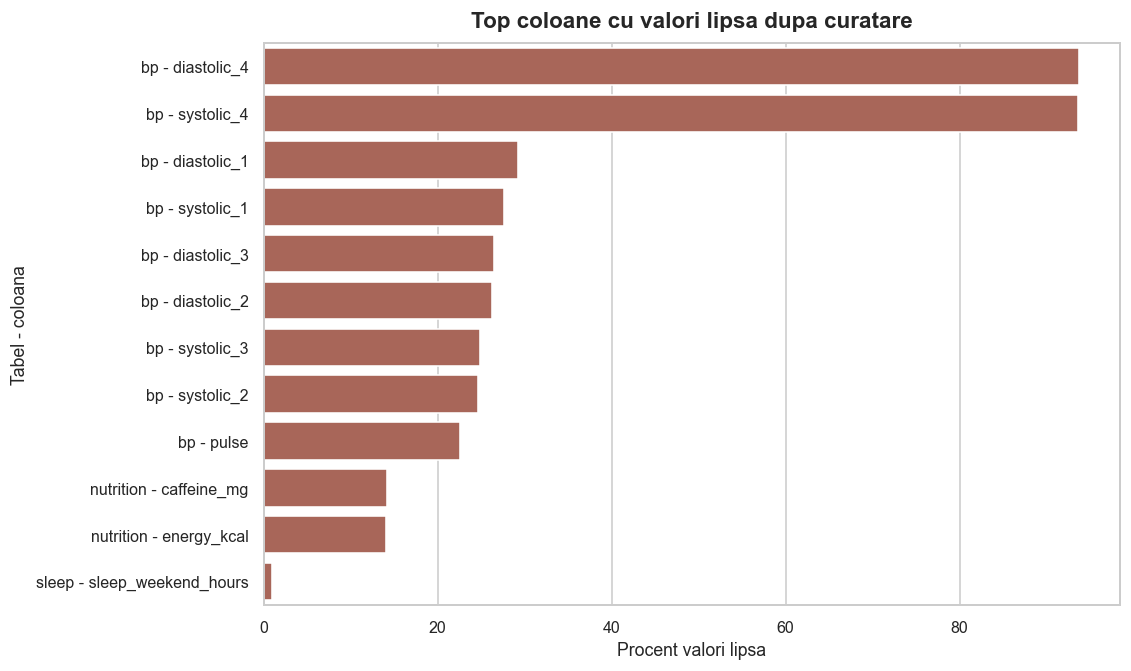

In [10]:
missing_plot_df = (
    missing_reports.loc[missing_reports["missing_pct"] > 0, ["table", "column", "missing_pct"]]
    .copy()
)
missing_plot_df["label"] = missing_plot_df["table"] + " - " + missing_plot_df["column"]
missing_plot_df = missing_plot_df.sort_values("missing_pct", ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_plot_df, x="missing_pct", y="label", color="#b55d4c")
plt.title("Top coloane cu valori lipsa dupa curatare")
plt.xlabel("Procent valori lipsa")
plt.ylabel("Tabel - coloana")
plt.tight_layout()
plt.show()


Graficul de mai sus arată unde se concentrează lipsurile după curățare. În interpretare contează nu doar cât lipsește, ci și **unde** lipsește: valorile absente din măsurători repetate de tensiune au un impact diferit față de lipsa unei variabile esențiale precum `pulse` sau `age`.

Metodologic, tratăm valorile biologic imposibile ca lipsă, nu ca observații valide. În același timp, nu eliminăm agresiv participanții doar pentru că le lipsește una dintre componentele somnului: pentru `avg_sleep_hours` folosim ulterior o medie ponderată care valorifică și cazurile parțial observate.


### 2.1 Inner join, retenția lotului și implicațiile metodologice

Pentru a obține un lot coerent, unim cele patru tabele prin `SEQN` folosind `inner join`. În contextul acestui proiect, asta înseamnă că păstrăm doar participanții care au date disponibile în **toate** sursele necesare.

Avantajul este clar: fiecare rând din lotul final poate fi analizat pe aceeași bază de variabile. Costul este însă important și merită spus explicit: lotul final devine un subset al participanților NHANES disponibili, iar această selecție poate reduce dimensiunea eșantionului și poate introduce bias de selecție.

Tocmai de aceea urmărim separat retenția participanților și comparăm pe scurt observațiile păstrate cu cele eliminate după join și filtrările esențiale.


In [11]:
analysis_required_columns = ["caffeine_mg", "energy_kcal", "pulse", "age"]

participant_union = pd.Index(pd.concat([
    nutrition_clean["SEQN"],
    bp_clean["SEQN"],
    sleep_clean["SEQN"],
    demographics_clean["SEQN"],
]).dropna().astype("Int64").unique())

merged_df = (
    nutrition_clean
    .merge(bp_clean, on="SEQN", how="inner")
    .merge(sleep_clean, on="SEQN", how="inner")
    .merge(demographics_clean, on="SEQN", how="inner")
)

analysis_df = merged_df.drop_duplicates().copy()
analysis_after_join = analysis_df.copy()

analysis_df = analysis_df[analysis_df["age"] >= 18].copy()
analysis_after_adult_filter = analysis_df.copy()

analysis_df = analysis_df.dropna(subset=analysis_required_columns).copy()

retention_summary = pd.DataFrame([
    {
        "stage": "Participanți unici disponibili în cel puțin o sursă curățată",
        "participants": len(participant_union),
    },
    {
        "stage": "Participanți comuni după inner join",
        "participants": analysis_after_join["SEQN"].nunique(),
    },
    {
        "stage": "După filtrarea la adulți (18+)",
        "participants": analysis_after_adult_filter["SEQN"].nunique(),
    },
    {
        "stage": "Lot final cu variabile esențiale",
        "participants": analysis_df["SEQN"].nunique(),
    },
])
retention_summary["retention_pct"] = (
    retention_summary["participants"] / retention_summary.loc[0, "participants"] * 100
).round(2)

retention_comparison = (
    analysis_after_join[["SEQN", "age", "caffeine_mg", "energy_kcal", "pulse"]]
    .assign(retained_final=lambda df: df["SEQN"].isin(analysis_df["SEQN"]))
    .groupby("retained_final")
    .agg(
        participants=("SEQN", "nunique"),
        age_mean=("age", "mean"),
        caffeine_mean=("caffeine_mg", "mean"),
        pulse_mean=("pulse", "mean"),
    )
    .round(2)
    .reset_index()
)
retention_comparison["status"] = retention_comparison["retained_final"].map({
    True: "Păstrați în lotul final",
    False: "Excluși dintre participanții comuni după filtrări",
})

join_summary = retention_summary.copy()

retention_md = f"""
**Rezumat metodologic al retenției**

- `inner join` păstrează doar participanții observați în toate cele patru surse.
- Lotul final conține **{analysis_df['SEQN'].nunique():,} adulți**, adică **{retention_summary.loc[retention_summary['stage'] == 'Lot final cu variabile esențiale', 'retention_pct'].iloc[0]:.2f}%** din participanții unici disponibili în cel puțin una dintre sursele curate.
- Această alegere crește coerența analizei, dar poate introduce bias de selecție, deoarece participanții păstrați pot arăta diferit față de cei excluși.
"""

display(retention_summary)
display(retention_comparison[["status", "participants", "age_mean", "caffeine_mean", "pulse_mean"]])
display(Markdown(retention_md))


,stage,participants,retention_pct
0,Participanți unici disponibili în cel puțin o ...,9254,100.00
1,Participanți comuni după inner join,5828,62.98
2,După filtrarea la adulți (18+),5533,59.79
3,Lot final cu variabile esențiale,4824,52.13


,status,participants,age_mean,caffeine_mean,pulse_mean
0,Excluși dintre participanții comuni după filtrări,1004,40.48,63.09,74.20
1,Păstrați în lotul final,4824,49.72,135.55,71.72



**Rezumat metodologic al retenției**

- `inner join` păstrează doar participanții observați în toate cele patru surse.
- Lotul final conține **4,824 adulți**, adică **52.13%** din participanții unici disponibili în cel puțin una dintre sursele curate.
- Această alegere crește coerența analizei, dar poate introduce bias de selecție, deoarece participanții păstrați pot arăta diferit față de cei excluși.


In [12]:
print("Tipuri de date in analysis_df:")
display(analysis_df.dtypes.to_frame("dtype"))

print("Statistici descriptive:")
display(analysis_df.describe(include="all").T)


Tipuri de date in analysis_df:


,dtype
SEQN,Int64
energy_kcal,float64
caffeine_mg,float64
pulse,float64
systolic_1,float64
diastolic_1,float64
systolic_2,float64
diastolic_2,float64
systolic_3,float64
diastolic_3,float64


Statistici descriptive:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SEQN,"4,824.00",<NA>,<NA>,<NA>,"98,286.99","2,682.07","93,705.00","95,952.75","98,299.50","100,582.25","102,956.00"
energy_kcal,"4,824.00",NaN,NaN,NaN,"2,103.09","1,002.61",3.00,"1,408.00","1,941.00","2,615.25","8,538.00"
caffeine_mg,"4,824.00",NaN,NaN,NaN,135.55,161.48,0.00,9.75,94.00,193.00,"1,211.00"
pulse,"4,824.00",NaN,NaN,NaN,71.72,11.58,42.00,64.00,70.00,78.00,136.00
systolic_1,"4,489.00",NaN,NaN,NaN,125.80,19.33,86.00,112.00,124.00,136.00,224.00
diastolic_1,"4,456.00",NaN,NaN,NaN,72.30,11.93,30.00,64.00,72.00,80.00,124.00
systolic_2,"4,701.00",NaN,NaN,NaN,126.14,19.92,80.00,112.00,124.00,136.00,236.00
diastolic_2,"4,678.00",NaN,NaN,NaN,72.60,11.97,30.00,64.00,72.00,80.00,126.00
systolic_3,"4,689.00",NaN,NaN,NaN,125.68,19.74,80.00,112.00,122.00,136.00,238.00
diastolic_3,"4,668.00",NaN,NaN,NaN,72.55,12.02,30.00,64.00,72.00,80.00,126.00


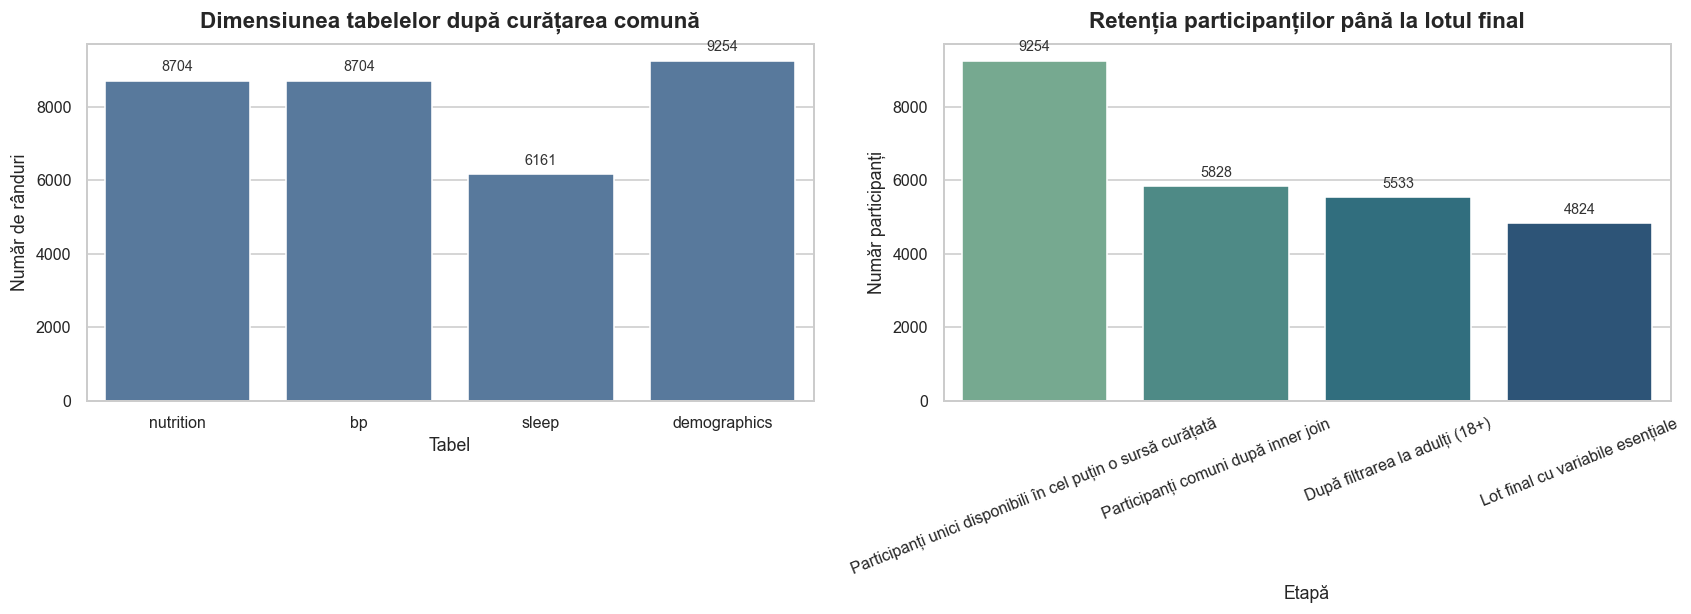

In [13]:
def annotate_bar_values_local(ax, fmt="{:.0f}"):
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=9,
            color="#333333",
        )

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

cleaning_plot_df = cleaning_summary.rename(columns={
    "rows_dupa_curatare_comuna": "rows",
    "table": "tabel",
})
sns.barplot(data=cleaning_plot_df, x="tabel", y="rows", ax=axes[0], color="#4c78a8")
axes[0].set_title("Dimensiunea tabelelor după curățarea comună")
axes[0].set_xlabel("Tabel")
axes[0].set_ylabel("Număr de rânduri")
annotate_bar_values_local(axes[0], fmt="{:.0f}")

sns.barplot(data=retention_summary, x="stage", y="participants", ax=axes[1], palette="crest")
axes[1].set_title("Retenția participanților până la lotul final")
axes[1].set_xlabel("Etapă")
axes[1].set_ylabel("Număr participanți")
axes[1].tick_params(axis="x", rotation=22)
annotate_bar_values_local(axes[1], fmt="{:.0f}")

plt.tight_layout()
plt.show()


Retenția participanților trebuie citită împreună cu logica de selecție. Lotul final nu reprezintă „toți participanții NHANES”, ci doar subsetul pentru care putem urmări, în mod coerent, cafeina, energia, somnul, pulsul și demografia.

Această alegere este justificată pentru analiza de față, dar poate favoriza participanții cu date mai complete și profiluri ușor diferite de cei excluși. Din acest motiv, concluziile trebuie interpretate ca rezultate pentru lotul final construit aici, nu ca afirmații universale despre întreaga populație.


#### Variabile derivate și de ce sunt utile

Înainte de EDA și modelare, construim câteva variabile derivate care fac datele mai ușor de interpretat și mai potrivite pentru comparații între participanți:

- `avg_sleep_hours`: medie săptămânală ponderată a somnului, cu **5 zile lucrătoare** și **2 zile de weekend**. Dacă una dintre componente lipsește, împărțirea se face doar la suma ponderilor disponibile, nu rigid la 7.
- `avg_systolic_bp`: media măsurătorilor sistolice disponibile pentru fiecare participant.
- `avg_diastolic_bp`: media măsurătorilor diastolice disponibile pentru fiecare participant.
- `caffeine_group`: grupare ordinală a consumului de cafeină (`Low`, `Moderate`, `High`, `Very High`) pentru comparații ușor de prezentat.
- `age_group`: grupare pe intervale de vârstă adulte, utilă în interpretarea descriptivă.
- `high_pulse`: variabilă binară pentru clasificare. Pragul de bază este `pulse > 90`, iar dacă acest prag nu produce suficiente cazuri pozitive, folosim ca fallback percentila 75 a pulsului, tocmai pentru a evita o clasă pozitivă aproape goală.

Aceste variabile nu schimbă sensul datelor brute, ci le rezumă într-o formă mai stabilă pentru comparații, grafice și modele.


In [14]:
systolic_columns = [col for col in ["systolic_1", "systolic_2", "systolic_3", "systolic_4"] if col in analysis_df.columns]
diastolic_columns = [col for col in ["diastolic_1", "diastolic_2", "diastolic_3", "diastolic_4"] if col in analysis_df.columns]

analysis_df["avg_systolic_bp"] = analysis_df[systolic_columns].mean(axis=1, skipna=True)
analysis_df["avg_diastolic_bp"] = analysis_df[diastolic_columns].mean(axis=1, skipna=True)

sleep_weight_sum = (
    analysis_df["sleep_weekday_hours"].notna().astype(int) * 5
    + analysis_df["sleep_weekend_hours"].notna().astype(int) * 2
)
sleep_weighted_sum = (
    analysis_df["sleep_weekday_hours"].fillna(0) * 5
    + analysis_df["sleep_weekend_hours"].fillna(0) * 2
)
analysis_df["avg_sleep_hours"] = sleep_weighted_sum / sleep_weight_sum.replace(0, np.nan)

analysis_df["caffeine_group"] = pd.cut(
    analysis_df["caffeine_mg"],
    bins=[-0.001, 50, 150, 300, np.inf],
    labels=["Low", "Moderate", "High", "Very High"],
    right=True
)

analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=[18, 30, 45, 60, np.inf],
    labels=["18-29", "30-44", "45-59", "60+"],
    right=False
)

default_high_pulse_threshold = 90
positive_count_default = int((analysis_df["pulse"] > default_high_pulse_threshold).sum())
min_positive_needed = max(30, int(0.05 * len(analysis_df)))

if positive_count_default >= min_positive_needed:
    high_pulse_threshold = default_high_pulse_threshold
    high_pulse_rule = "prag fix de 90 bpm"
else:
    high_pulse_threshold = float(analysis_df["pulse"].quantile(0.75))
    high_pulse_rule = "fallback la percentila 75 a pulsului"

analysis_df["high_pulse"] = (analysis_df["pulse"] > high_pulse_threshold).astype(int)

analysis_df["caffeine_group"] = pd.Categorical(
    analysis_df["caffeine_group"],
    categories=["Low", "Moderate", "High", "Very High"],
    ordered=True
)

analysis_df["age_group"] = pd.Categorical(
    analysis_df["age_group"],
    categories=["18-29", "30-44", "45-59", "60+"],
    ordered=True
)

sleep_component_availability = pd.DataFrame([
    {
        "configurație": "ambele componente disponibile",
        "participanți": int(((analysis_df["sleep_weekday_hours"].notna()) & (analysis_df["sleep_weekend_hours"].notna())).sum()),
    },
    {
        "configurație": "doar componenta din zile lucrătoare",
        "participanți": int(((analysis_df["sleep_weekday_hours"].notna()) & (analysis_df["sleep_weekend_hours"].isna())).sum()),
    },
    {
        "configurație": "doar componenta din weekend",
        "participanți": int(((analysis_df["sleep_weekday_hours"].isna()) & (analysis_df["sleep_weekend_hours"].notna())).sum()),
    },
    {
        "configurație": "niciuna disponibilă",
        "participanți": int(((analysis_df["sleep_weekday_hours"].isna()) & (analysis_df["sleep_weekend_hours"].isna())).sum()),
    },
])

derived_variables_summary = pd.DataFrame([
    {"variabilă": "avg_systolic_bp", "descriere": "media măsurătorilor sistolice disponibile"},
    {"variabilă": "avg_diastolic_bp", "descriere": "media măsurătorilor diastolice disponibile"},
    {"variabilă": "avg_sleep_hours", "descriere": "medie săptămânală ponderată, calculată pe ponderile disponibile"},
    {"variabilă": "caffeine_group", "descriere": "grupare ordinală: <=50, 50-150, 150-300, >300 mg"},
    {"variabilă": "age_group", "descriere": "grupe adulte: 18-29, 30-44, 45-59, 60+"},
    {"variabilă": "high_pulse", "descriere": "indicator binar pentru clasificare"},
])

high_pulse_summary = pd.DataFrame([
    {
        "prag_folosit": round(float(high_pulse_threshold), 2),
        "regulă": high_pulse_rule,
        "cazuri_pozitive": int(analysis_df["high_pulse"].sum()),
        "procent_pozitive": round(float(analysis_df["high_pulse"].mean() * 100), 2),
    }
])

print("`avg_sleep_hours` folosește o medie săptămânală ponderată, iar împărțirea se face doar la suma ponderilor disponibile.")
display(derived_variables_summary)
display(sleep_component_availability)
display(high_pulse_summary)


`avg_sleep_hours` folosește o medie săptămânală ponderată, iar împărțirea se face doar la suma ponderilor disponibile.


,variabilă,descriere
0,avg_systolic_bp,media măsurătorilor sistolice disponibile
1,avg_diastolic_bp,media măsurătorilor diastolice disponibile
2,avg_sleep_hours,"medie săptămânală ponderată, calculată pe pond..."
3,caffeine_group,"grupare ordinală: <=50, 50-150, 150-300, >300 mg"
4,age_group,"grupe adulte: 18-29, 30-44, 45-59, 60+"
5,high_pulse,indicator binar pentru clasificare


,configurație,participanți
0,ambele componente disponibile,4772
1,doar componenta din zile lucrătoare,15
2,doar componenta din weekend,10
3,niciuna disponibilă,27


,prag_folosit,regulă,cazuri_pozitive,procent_pozitive
0,90.00,prag fix de 90 bpm,268,5.56


In [15]:
analysis_df.to_csv("final_merged_dataset.csv", index=False)
print("[OK] final_merged_dataset.csv a fost salvat.")

display(analysis_df[[
    "SEQN", "energy_kcal", "caffeine_mg", "pulse",
    "avg_sleep_hours", "avg_systolic_bp", "avg_diastolic_bp",
    "age", "gender", "caffeine_group", "age_group", "high_pulse"
]].head())


[OK] final_merged_dataset.csv a fost salvat.


,SEQN,energy_kcal,caffeine_mg,pulse,avg_sleep_hours,avg_systolic_bp,avg_diastolic_bp,age,gender,caffeine_group,age_group,high_pulse
0,93705,"1,202.00",361.00,52.00,8.00,200.00,68.00,66.00,Female,Very High,60+,0
1,93706,"1,987.00",0.00,82.00,10.79,111.33,73.33,18.00,Male,Low,18-29,0
2,93708,"1,251.00",33.00,68.00,8.00,142.00,76.00,66.00,Female,Low,60+,0
4,93711,"2,840.00",347.00,62.00,7.57,101.33,66.67,56.00,Male,Very High,45-59,0
5,93712,"2,045.00",0.00,68.00,7.93,113.33,70.00,18.00,Male,Low,18-29,0


## Etapa 3: Analiză exploratorie și interpretare

După construirea lotului final, trecem la partea exploratorie. Scopul nu este să acumulăm grafice, ci să răspundem progresiv la câteva întrebări clare:

1. Cum arată distribuțiile variabilelor principale?
2. Cât de dispersate sunt datele și cum tratăm valorile extreme?
3. Se observă diferențe între grupele de cafeină?
4. Ce relații se văd între cafeină, somn, puls și celelalte variabile?
5. Care este imaginea de ansamblu pe care merită să o ducem în modelare?

Astfel, fiecare grup de vizualizări are un rol precis în povestea notebook-ului și pregătește natural pasul următor.


In [16]:
def annotate_bar_values(ax, orientation="v", fmt="{:.0f}", color="#333333"):
    if orientation == "v":
        for patch in ax.patches:
            height = patch.get_height()
            ax.annotate(
                fmt.format(height),
                (patch.get_x() + patch.get_width() / 2, height),
                ha="center",
                va="bottom",
                xytext=(0, 4),
                textcoords="offset points",
                fontsize=9,
                color=color,
            )
    else:
        for patch in ax.patches:
            width = patch.get_width()
            ax.annotate(
                fmt.format(width),
                (width, patch.get_y() + patch.get_height() / 2),
                ha="left",
                va="center",
                xytext=(5, 0),
                textcoords="offset points",
                fontsize=9,
                color=color,
            )


def show_distribution_plots(df):
    columns_to_plot = [
        ("caffeine_mg", "Distribuția consumului de cafeină în lotul final", "Cafeină (mg)"),
        ("energy_kcal", "Distribuția aportului energetic zilnic", "Energie (kcal)"),
        ("pulse", "Distribuția pulsului în lotul final", "Puls (bătăi/minut)"),
        ("avg_sleep_hours", "Distribuția somnului mediu ponderat", "Somn mediu ponderat (ore)"),
        ("age", "Distribuția vârstei participanților", "Vârstă (ani)"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()

    for ax, (column, title, xlabel) in zip(axes, columns_to_plot):
        series = df[column].dropna()
        sns.histplot(series, bins=30, kde=True, ax=ax, color="#2a7f62")
        ax.axvline(series.median(), color="#d62828", linestyle="--", linewidth=1.4, label="Mediană")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frecvență")
        ax.legend(loc="upper right", fontsize=9)

    axes[-1].axis("off")
    plt.tight_layout()
    plt.show()


def ordered_barplot(data, x, y, title, xlabel, ylabel, palette="crest", annotate=True, fmt="{:.0f}"):
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=data, x=x, y=y, palette=palette)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if annotate:
        annotate_bar_values(ax, orientation="v", fmt=fmt)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def violin_boxplot(ax, data, x, y, title, xlabel, ylabel, palette, order=None):
    sns.violinplot(
        data=data,
        x=x,
        y=y,
        order=order,
        palette=palette,
        inner=None,
        cut=0,
        linewidth=0,
        saturation=0.85,
        ax=ax,
    )
    sns.boxplot(
        data=data,
        x=x,
        y=y,
        order=order,
        width=0.18,
        showcaps=True,
        showfliers=False,
        boxprops={"facecolor": "white", "alpha": 0.92, "zorder": 3},
        whiskerprops={"linewidth": 1.2},
        medianprops={"color": "#1f1f1f", "linewidth": 1.6},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def lollipop_plot(ax, data, category_col, value_col, title, xlabel, ylabel, color, label_fmt="{:.2f}"):
    y_pos = np.arange(len(data))
    ax.hlines(y=y_pos, xmin=0, xmax=data[value_col], color=color, linewidth=2, alpha=0.8)
    ax.scatter(data[value_col], y_pos, color=color, s=80, zorder=3)
    for ypos, value in zip(y_pos, data[value_col]):
        ax.text(value, ypos, f"  {label_fmt.format(value)}", va="center", ha="left", fontsize=9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(data[category_col])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


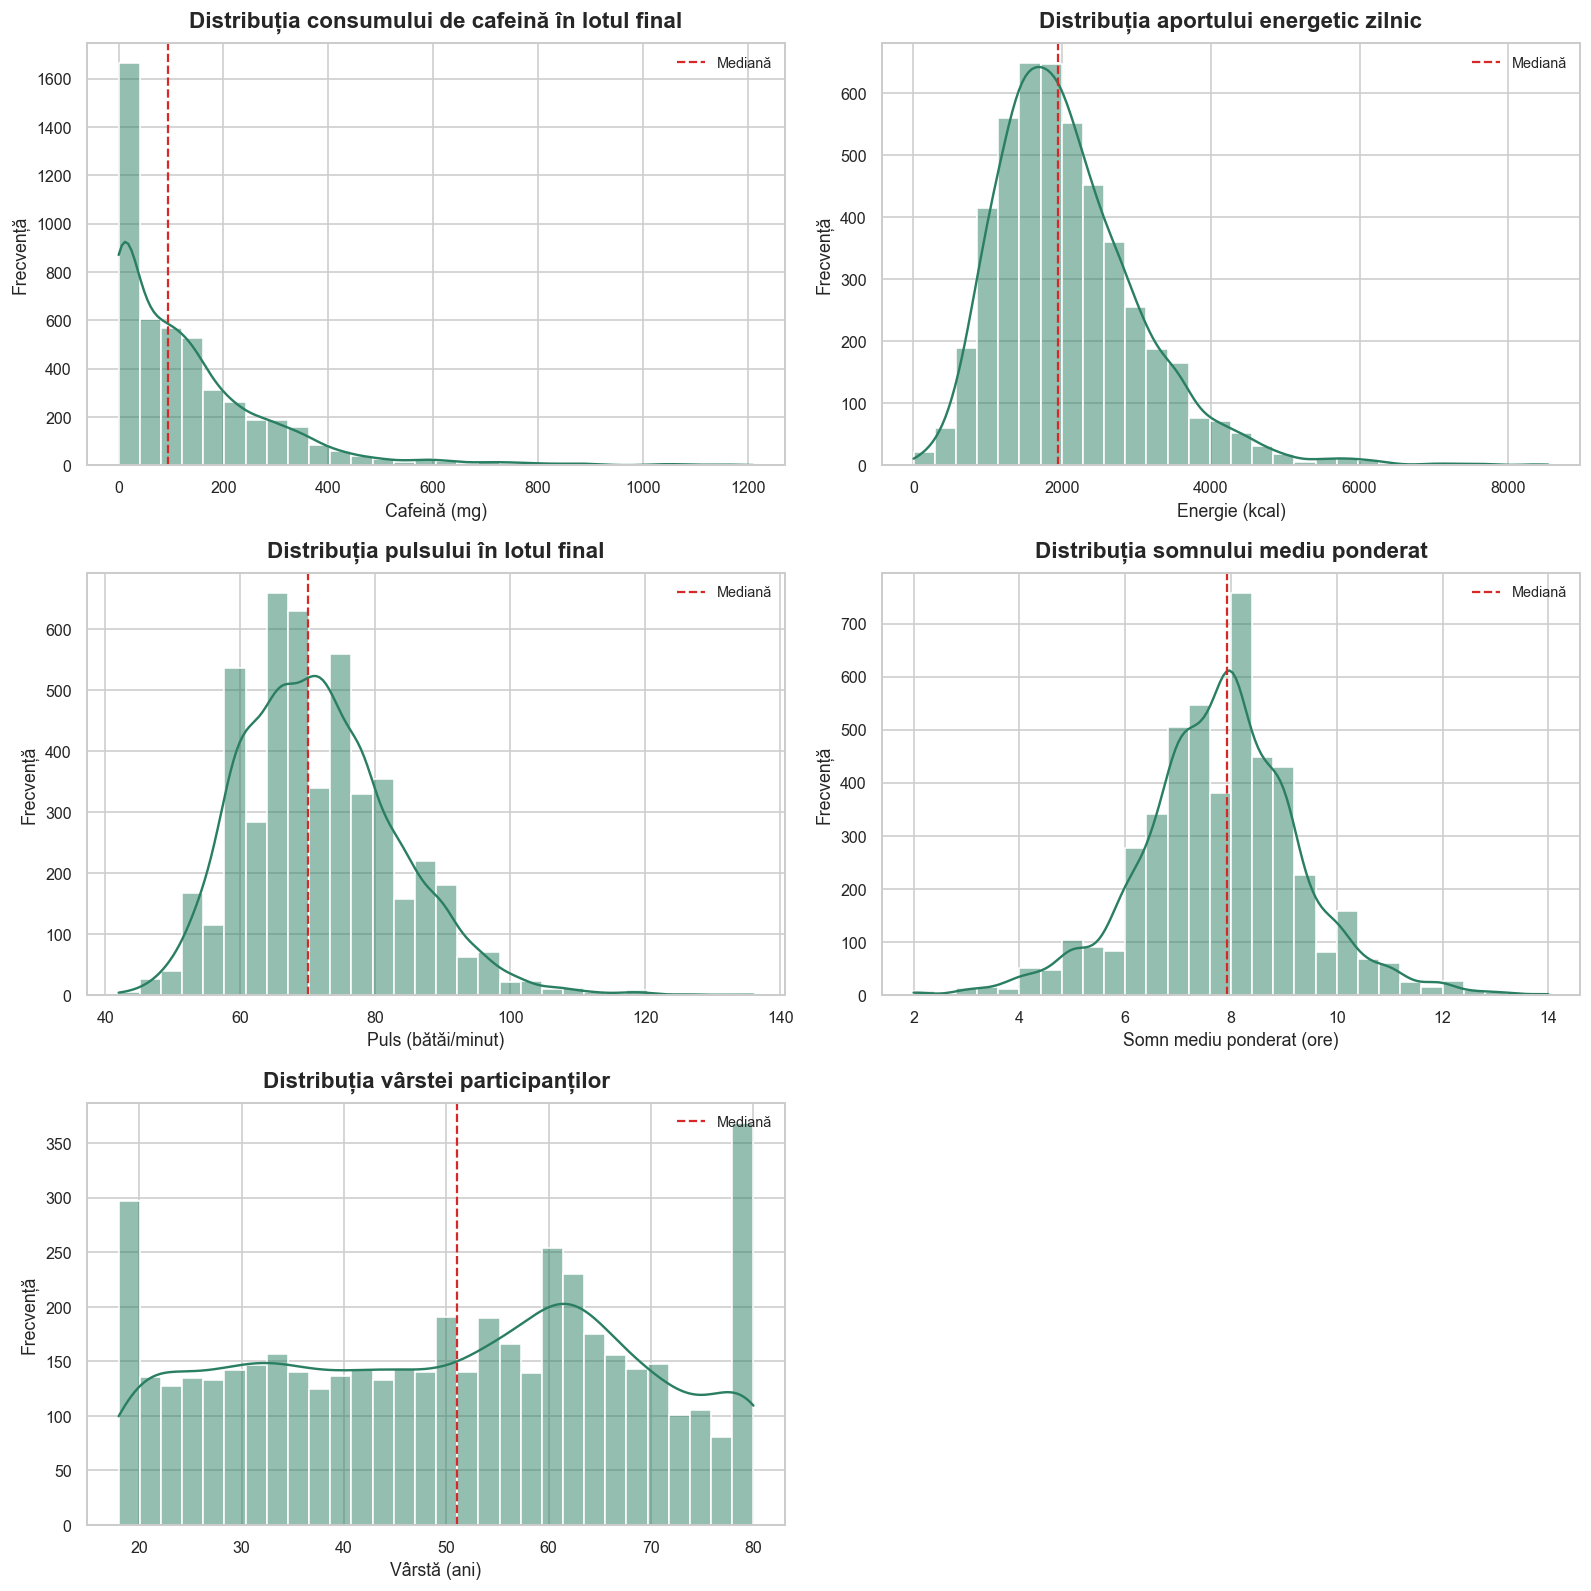

In [17]:
show_distribution_plots(analysis_df)


### Întrebarea 1. Cum arată distribuțiile variabilelor principale?

Histogramele ne ajută să vedem rapid forma generală a datelor: asimetrie, dispersie, zone de concentrare și eventuale valori foarte mari. Pentru acest proiect, ele sunt importante mai ales fiindcă arată de la început că variabilele nu au distribuții perfect simetrice și că unele relații vor trebui interpretate cu prudență.

Primele observații sunt coerente cu natura datelor:
- `caffeine_mg` și `energy_kcal` tind să fie asimetrice spre dreapta;
- `avg_sleep_hours` trebuie citită ca medie săptămânală ponderată, nu ca o simplă medie între două coloane;
- apar valori ridicate, dar simpla lor prezență nu justifică automat eliminarea.


### Întrebarea 2. Cât de dispersate sunt datele și ce facem cu valorile extreme?

După distribuțiile de bază, verificăm mai formal dispersia variabilelor prin quartile, IQR și boxplot-uri. Aceste instrumente nu sunt folosite pentru a „curăța” forțat datele, ci pentru a înțelege cât de mare este variabilitatea și unde apar valorile neobișnuite.


### Decizia metodologică privind outlierii

În acest notebook facem o diferență clară între două situații:
- **valori imposibile sau evident invalide**, care sunt tratate ca lipsă;
- **valori extreme, dar biologic plauzibile**, care sunt păstrate.

Cu alte cuvinte, tabelul IQR și boxplot-urile sunt instrumente de înțelegere a distribuțiilor, nu un pretext pentru a netezi artificial datele. Într-un context observațional, variabilitatea reală este parte din semnal și merită păstrată cât timp rămâne plauzibilă.


In [18]:
iqr_columns = [
    "caffeine_mg",
    "energy_kcal",
    "pulse",
    "avg_sleep_hours",
    "age",
    "avg_systolic_bp",
    "avg_diastolic_bp",
]

iqr_summary_rows = []

for column in iqr_columns:
    series = analysis_df[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()

    iqr_summary_rows.append({
        "variabilă": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limită_inferioară": lower_bound,
        "limită_superioară": upper_bound,
        "outlieri_identificați": int(outlier_count),
        "procent_outlieri": round(float(outlier_count / len(series) * 100), 2),
    })

iqr_summary = pd.DataFrame(iqr_summary_rows).round(3)
display(iqr_summary)


,variabilă,Q1,Q3,IQR,limită_inferioară,limită_superioară,outlieri_identificați,procent_outlieri
0,caffeine_mg,9.75,193.00,183.25,-265.12,467.88,197,4.08
1,energy_kcal,"1,408.00","2,615.25","1,207.25",-402.88,"4,426.12",133,2.76
2,pulse,64.00,78.00,14.00,43.00,99.00,90,1.87
3,avg_sleep_hours,7.00,8.71,1.71,4.43,11.29,189,3.94
4,age,34.00,64.00,30.00,-11.00,109.00,0,0.00
5,avg_systolic_bp,112.00,136.67,24.67,75.00,173.67,128,2.66
6,avg_diastolic_bp,65.33,80.00,14.67,43.33,102.00,81,1.69


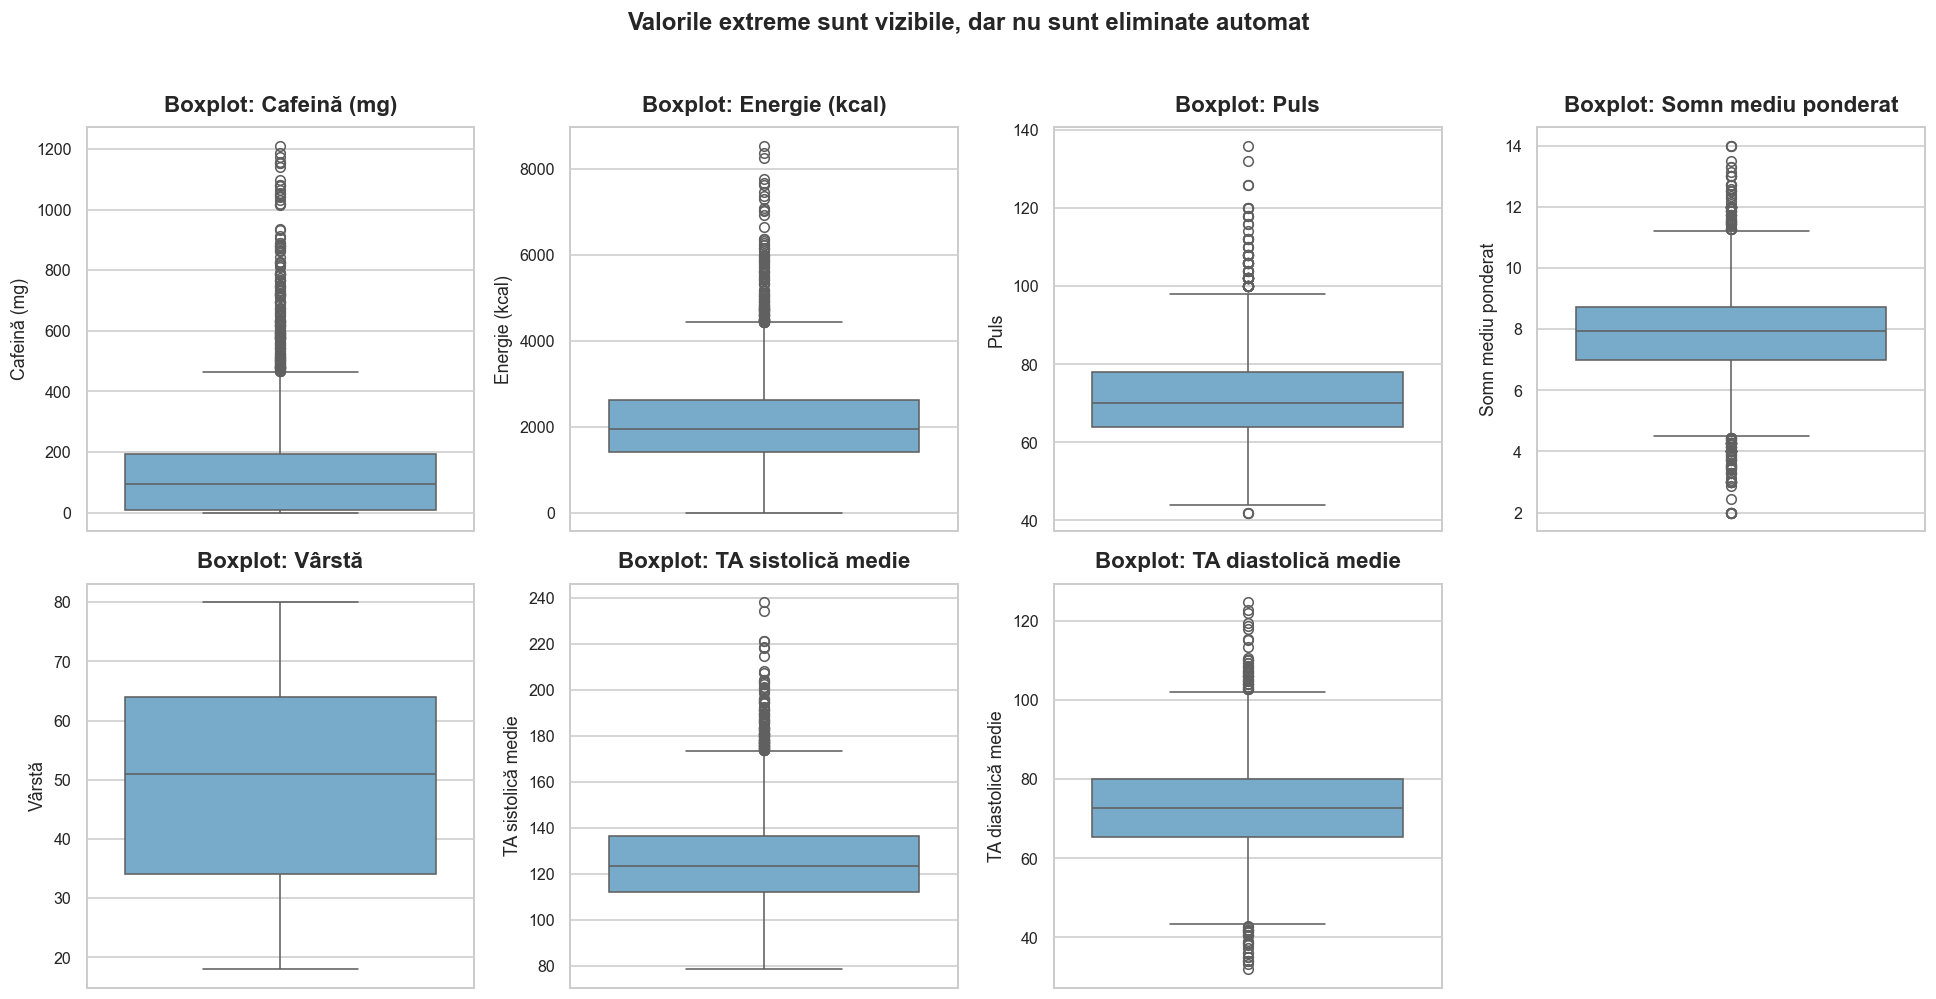

In [19]:
boxplot_columns = [
    ("caffeine_mg", "Cafeină (mg)"),
    ("energy_kcal", "Energie (kcal)"),
    ("pulse", "Puls"),
    ("avg_sleep_hours", "Somn mediu ponderat"),
    ("age", "Vârstă"),
    ("avg_systolic_bp", "TA sistolică medie"),
    ("avg_diastolic_bp", "TA diastolică medie"),
]

fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
axes = axes.flatten()

for ax, (column, label) in zip(axes, boxplot_columns):
    sns.boxplot(y=analysis_df[column], ax=ax, color="#6baed6")
    ax.set_title(f"Boxplot: {label}")
    ax.set_xlabel("")
    ax.set_ylabel(label)

axes[-1].axis("off")
plt.suptitle("Valorile extreme sunt vizibile, dar nu sunt eliminate automat", y=1.02, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


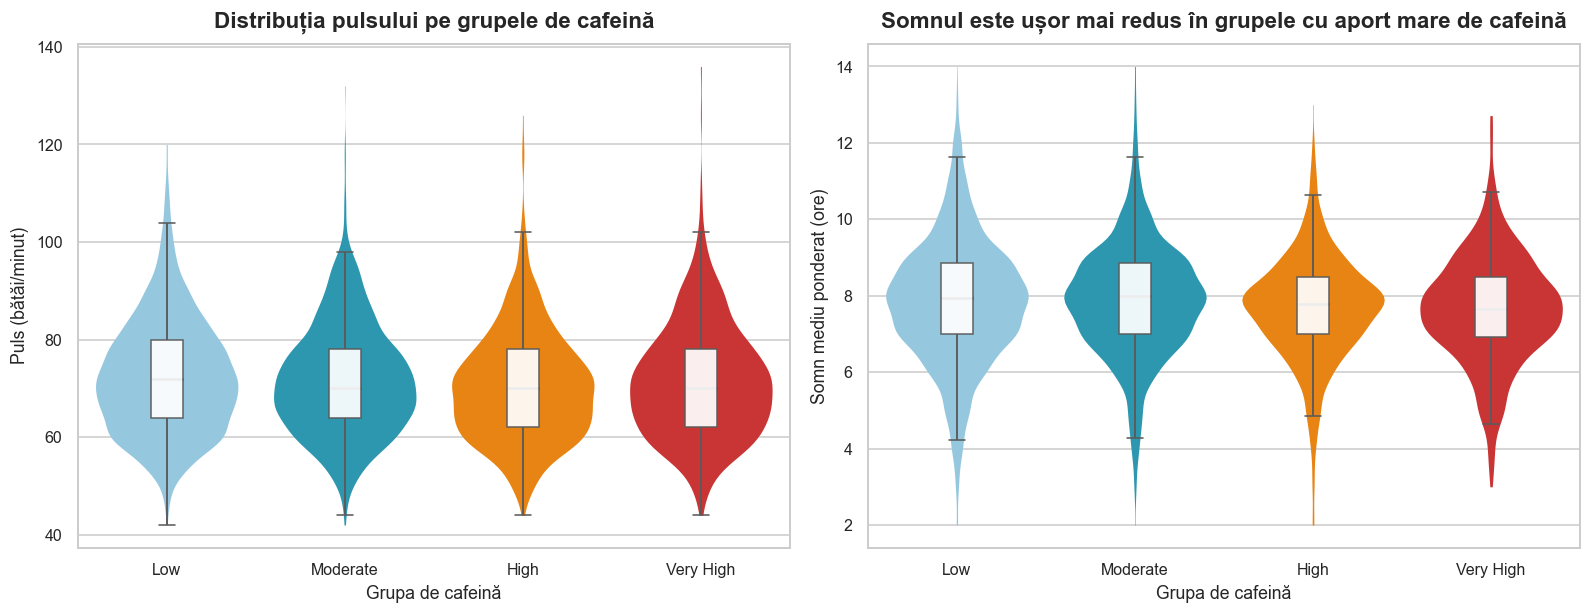

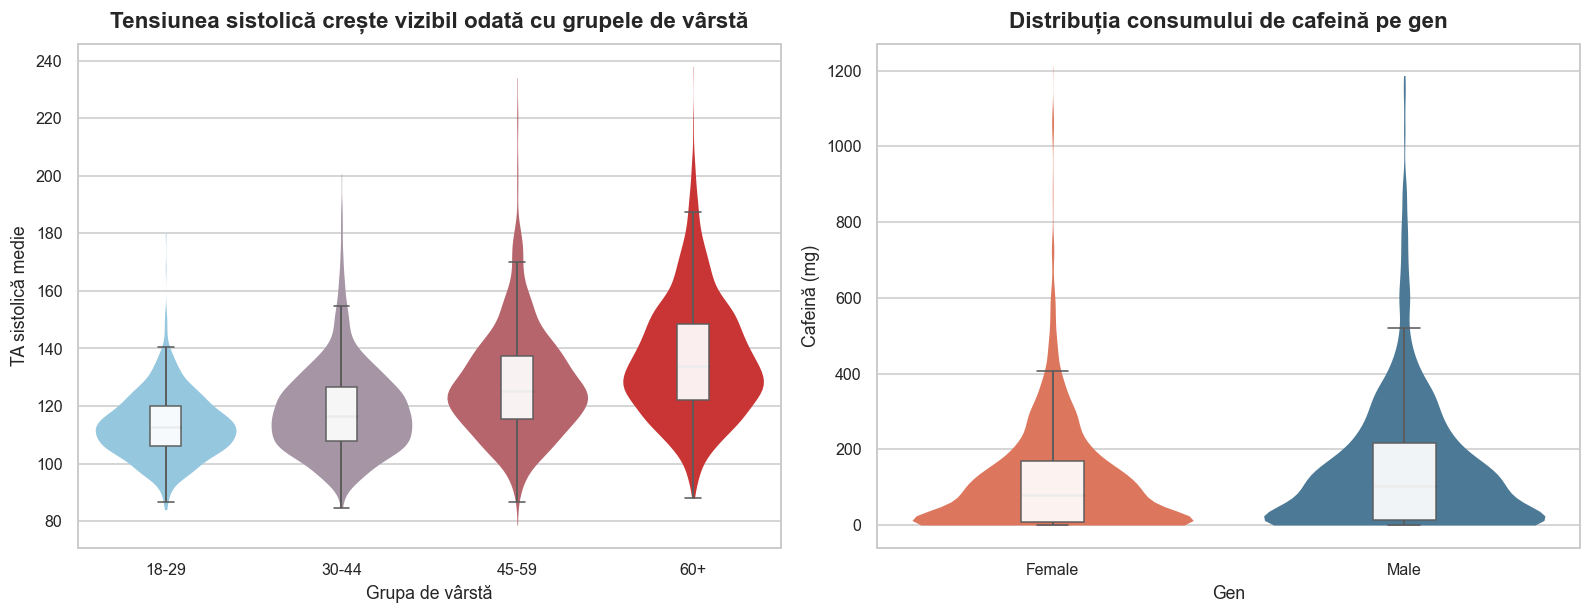

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

violin_boxplot(
    axes[0],
    analysis_df,
    x="caffeine_group",
    y="pulse",
    title="Distribuția pulsului pe grupele de cafeină",
    xlabel="Grupa de cafeină",
    ylabel="Puls (bătăi/minut)",
    palette=caffeine_palette,
    order=["Low", "Moderate", "High", "Very High"],
)

violin_boxplot(
    axes[1],
    analysis_df,
    x="caffeine_group",
    y="avg_sleep_hours",
    title="Somnul este ușor mai redus în grupele cu aport mare de cafeină",
    xlabel="Grupa de cafeină",
    ylabel="Somn mediu ponderat (ore)",
    palette=caffeine_palette,
    order=["Low", "Moderate", "High", "Very High"],
)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

age_palette = sns.color_palette("blend:#8ecae6,#d62828", n_colors=4)
gender_order = [g for g in ["Female", "Male", "Unknown"] if g in analysis_df["gender"].dropna().unique()]

violin_boxplot(
    axes[0],
    analysis_df,
    x="age_group",
    y="avg_systolic_bp",
    title="Tensiunea sistolică crește vizibil odată cu grupele de vârstă",
    xlabel="Grupa de vârstă",
    ylabel="TA sistolică medie",
    palette=age_palette,
    order=["18-29", "30-44", "45-59", "60+"],
)

violin_boxplot(
    axes[1],
    analysis_df,
    x="gender",
    y="caffeine_mg",
    title="Distribuția consumului de cafeină pe gen",
    xlabel="Gen",
    ylabel="Cafeină (mg)",
    palette=gender_palette,
    order=gender_order,
)

plt.tight_layout()
plt.show()


### Întrebarea 3. Se observă diferențe între grupele de cafeină?

Compararea grupurilor este utilă pentru prezentare, dar și pentru a vedea dacă ipoteza inițială capătă o formă recognoscibilă în date. Violin plot-urile și boxplot-urile sunt potrivite aici deoarece arată simultan distribuția, medianele și suprapunerile dintre grupuri.

Interpretarea trebuie să rămână prudentă: diferențele există, dar suprapunerile rămân importante. Tocmai această combinație sugerează că, dacă există semnal, el este mai degrabă modest decât puternic.


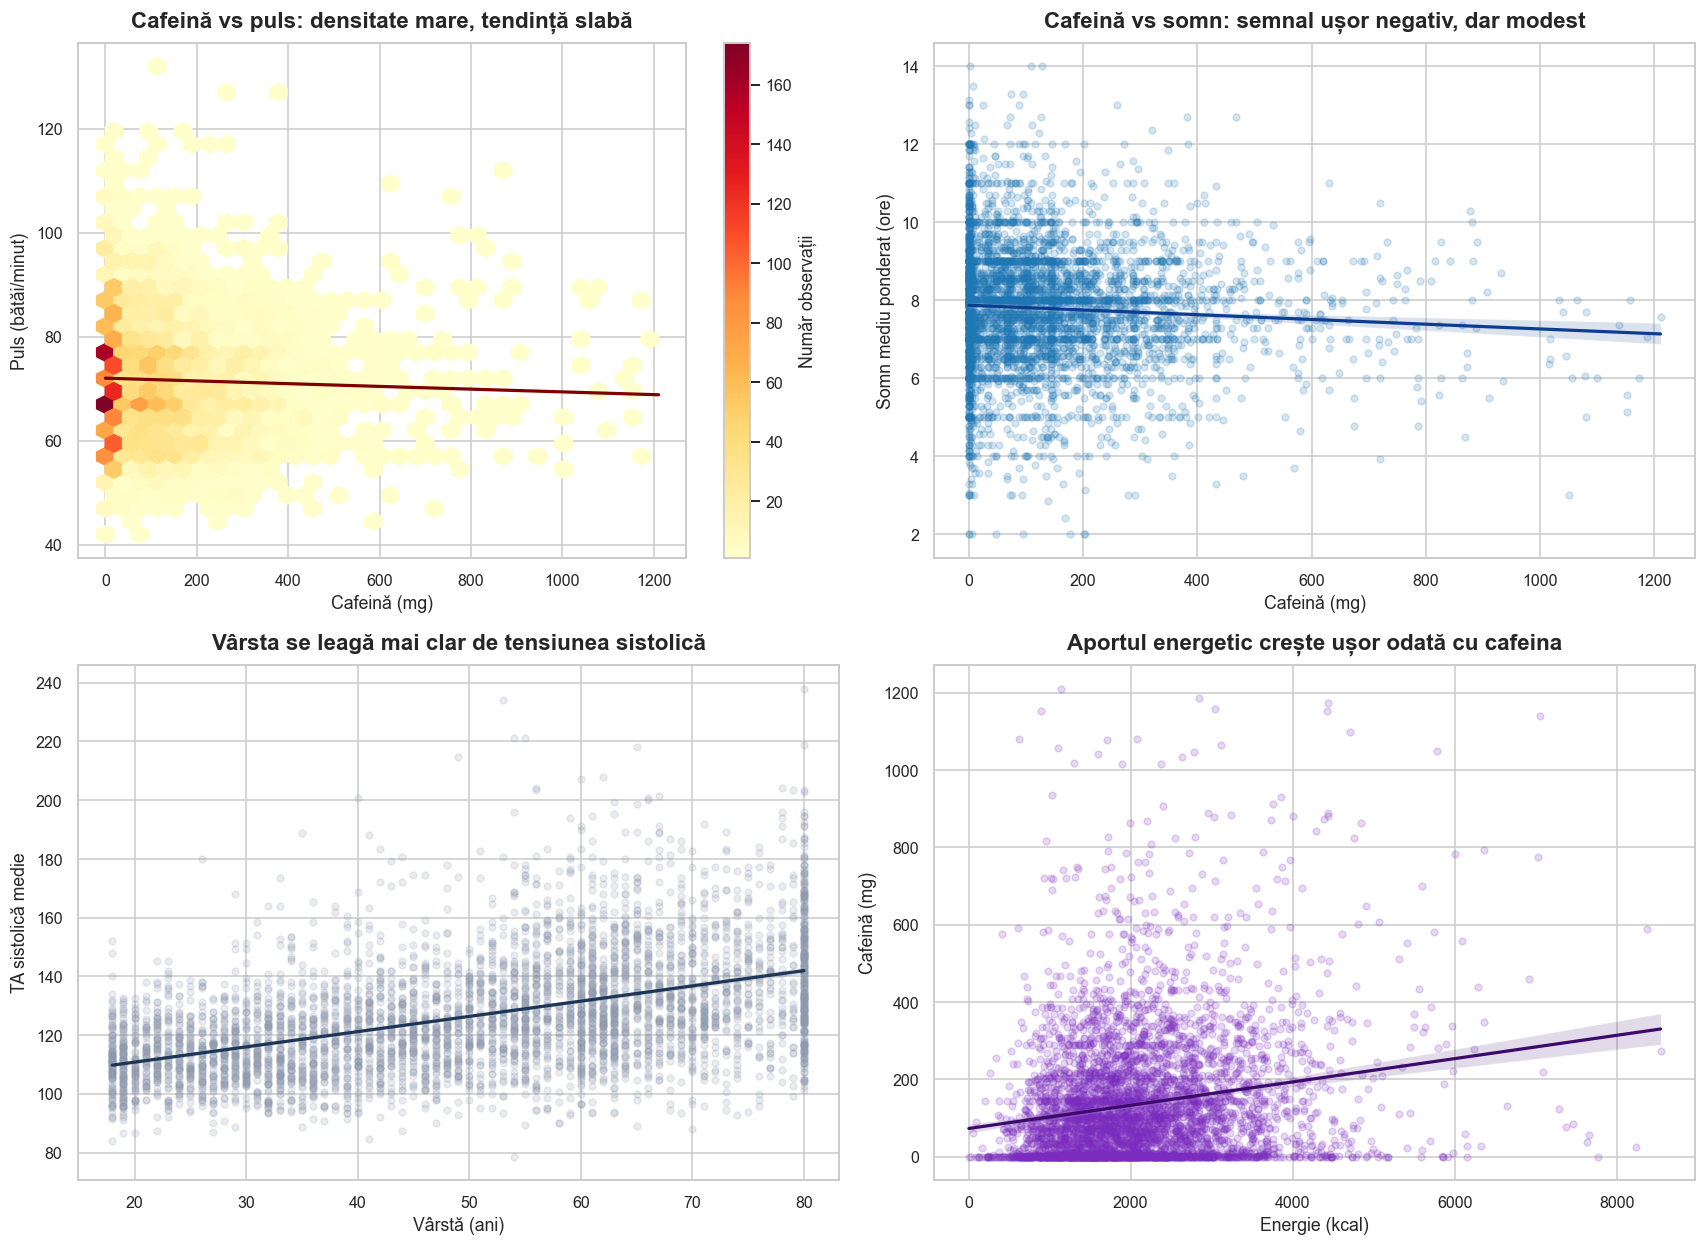

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

scatter_df = analysis_df[[
    "caffeine_mg",
    "pulse",
    "avg_sleep_hours",
    "energy_kcal",
    "age",
    "avg_systolic_bp",
]].dropna()

ax = axes[0, 0]
hb1 = ax.hexbin(
    scatter_df["caffeine_mg"],
    scatter_df["pulse"],
    gridsize=32,
    cmap="YlOrRd",
    mincnt=1,
)
trend_coef = np.polyfit(scatter_df["caffeine_mg"], scatter_df["pulse"], 1)
x_line = np.linspace(scatter_df["caffeine_mg"].min(), scatter_df["caffeine_mg"].max(), 200)
ax.plot(x_line, trend_coef[0] * x_line + trend_coef[1], color="#7f0000", linewidth=2)
ax.set_title("Cafeină vs puls: densitate mare, tendință slabă")
ax.set_xlabel("Cafeină (mg)")
ax.set_ylabel("Puls (bătăi/minut)")
plt.colorbar(hb1, ax=ax, label="Număr observații")

ax = axes[0, 1]
sns.regplot(
    data=scatter_df,
    x="caffeine_mg",
    y="avg_sleep_hours",
    scatter_kws={"alpha": 0.18, "s": 18, "color": "#1f77b4"},
    line_kws={"color": "#0b3d91", "linewidth": 2},
    ax=ax,
)
ax.set_title("Cafeină vs somn: semnal ușor negativ, dar modest")
ax.set_xlabel("Cafeină (mg)")
ax.set_ylabel("Somn mediu ponderat (ore)")

ax = axes[1, 0]
sns.regplot(
    data=scatter_df,
    x="age",
    y="avg_systolic_bp",
    scatter_kws={"alpha": 0.18, "s": 18, "color": "#8d99ae"},
    line_kws={"color": "#1d3557", "linewidth": 2},
    ax=ax,
)
ax.set_title("Vârsta se leagă mai clar de tensiunea sistolică")
ax.set_xlabel("Vârstă (ani)")
ax.set_ylabel("TA sistolică medie")

ax = axes[1, 1]
sns.regplot(
    data=scatter_df,
    x="energy_kcal",
    y="caffeine_mg",
    scatter_kws={"alpha": 0.18, "s": 18, "color": "#7b2cbf"},
    line_kws={"color": "#3c096c", "linewidth": 2},
    ax=ax,
)
ax.set_title("Aportul energetic crește ușor odată cu cafeina")
ax.set_xlabel("Energie (kcal)")
ax.set_ylabel("Cafeină (mg)")

plt.tight_layout()
plt.show()


### Întrebarea 4. Ce relații se văd între cafeină, somn, puls și ceilalți predictori?

Graficele de relație ne ajută să vedem dacă pattern-urile sugerate de distribuții și comparații pe grupuri se păstrează și la nivel continuu. Liniile de trend trebuie citite doar ca ghid vizual, nu ca argument de cauzalitate.

În practică, această secțiune este importantă pentru două motive:
- arată dacă relațiile dintre `caffeine_mg`, `pulse` și `avg_sleep_hours` sunt suficient de clare încât să merite urmărite mai departe;
- pune în context și relații mai stabile, precum cea dintre vârstă și tensiunea sistolică.


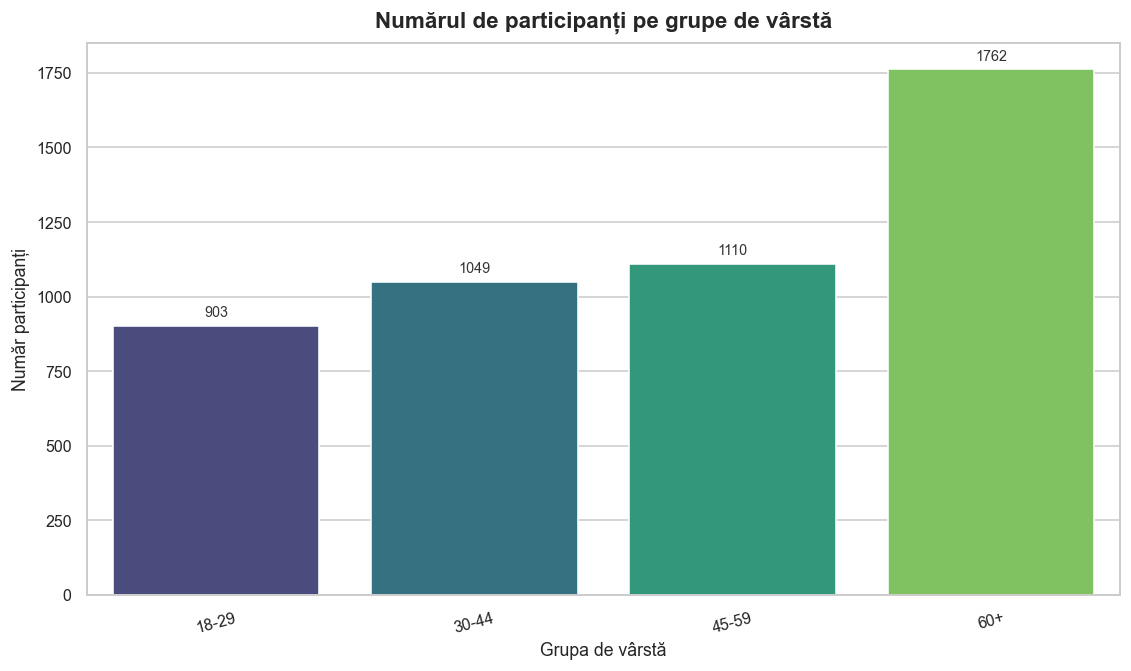

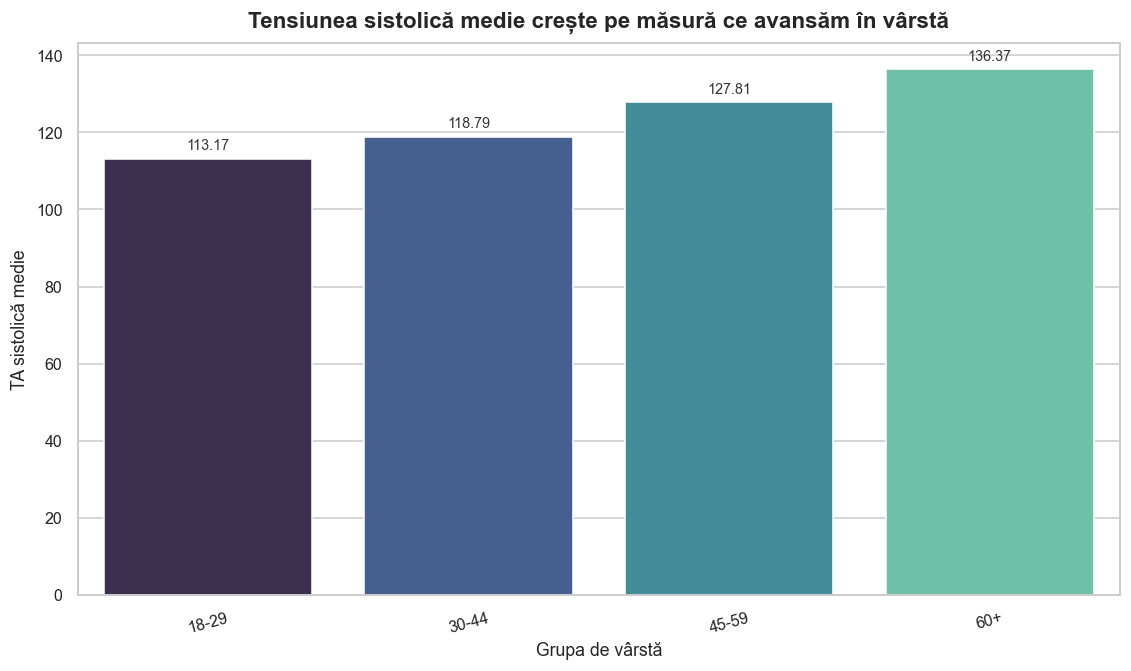

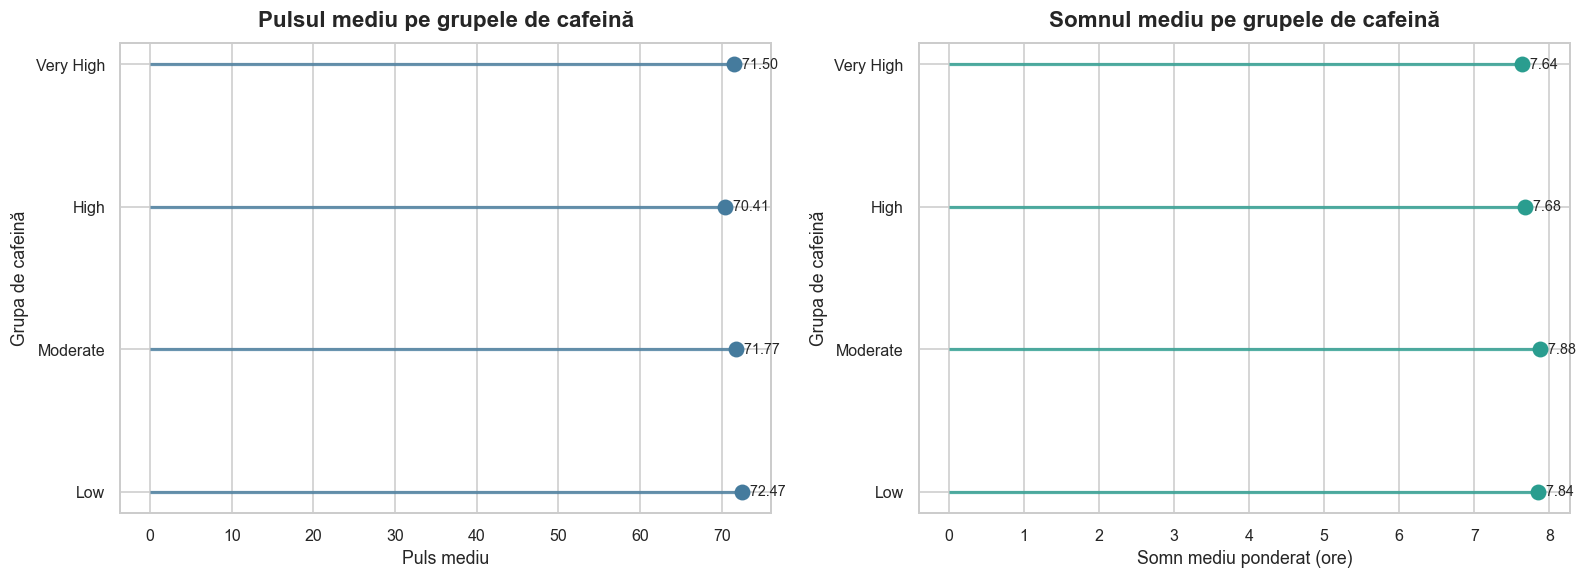

In [22]:
age_group_counts = (
    analysis_df["age_group"]
    .value_counts()
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="participants")
)

mean_systolic_by_age = (
    analysis_df.groupby("age_group", observed=False)["avg_systolic_bp"]
    .mean()
    .reset_index()
)

mean_pulse_by_caffeine = (
    analysis_df.groupby("caffeine_group", observed=False)["pulse"]
    .mean()
    .reset_index()
)

mean_sleep_by_caffeine = (
    analysis_df.groupby("caffeine_group", observed=False)["avg_sleep_hours"]
    .mean()
    .reset_index()
)

ordered_barplot(
    age_group_counts,
    x="age_group",
    y="participants",
    title="Numărul de participanți pe grupe de vârstă",
    xlabel="Grupa de vârstă",
    ylabel="Număr participanți",
    palette="viridis",
    fmt="{:.0f}"
)

ordered_barplot(
    mean_systolic_by_age,
    x="age_group",
    y="avg_systolic_bp",
    title="Tensiunea sistolică medie crește pe măsură ce avansăm în vârstă",
    xlabel="Grupa de vârstă",
    ylabel="TA sistolică medie",
    palette="mako",
    fmt="{:.2f}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

lollipop_plot(
    axes[0],
    mean_pulse_by_caffeine,
    category_col="caffeine_group",
    value_col="pulse",
    title="Pulsul mediu pe grupele de cafeină",
    xlabel="Puls mediu",
    ylabel="Grupa de cafeină",
    color="#457b9d",
    label_fmt="{:.2f}"
)

lollipop_plot(
    axes[1],
    mean_sleep_by_caffeine,
    category_col="caffeine_group",
    value_col="avg_sleep_hours",
    title="Somnul mediu pe grupele de cafeină",
    xlabel="Somn mediu ponderat (ore)",
    ylabel="Grupa de cafeină",
    color="#2a9d8f",
    label_fmt="{:.2f}"
)

plt.tight_layout()
plt.show()


Mediile pe grupuri comprimă informația și sunt utile mai ales pentru prezentare orală. Ele nu înlocuiesc distribuțiile complete, dar ne ajută să spunem rapid dacă diferențele dintre grupe sunt mari, mici sau greu de separat de variabilitatea internă.

În acest punct ne interesează două lucruri:
- dacă grupele de cafeină produc contraste clare pentru `pulse` și `avg_sleep_hours`;
- dacă alte relații, cum ar fi cea dintre vârstă și tensiunea arterială, ies mai clar decât cele legate direct de cafeină.


Cum se citește heatmap-ul de corelație:
- valori aproape de 1: relație directă
- valori aproape de -1: relație inversă
- valori aproape de 0: relație liniară slabă sau absentă


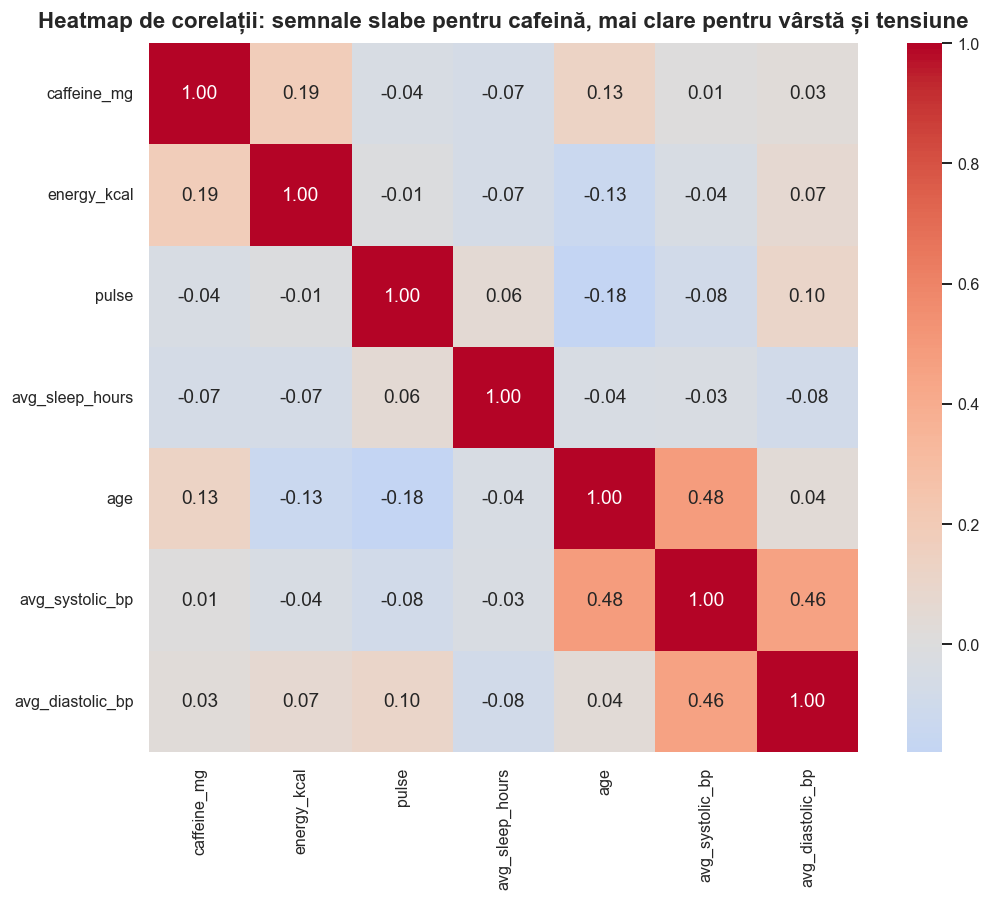

,caffeine_mg,energy_kcal,pulse,avg_sleep_hours,age,avg_systolic_bp,avg_diastolic_bp
caffeine_mg,1.00,0.19,-0.04,-0.07,0.12,0.01,0.03
energy_kcal,0.19,1.00,-0.01,-0.07,-0.13,-0.04,0.07
pulse,-0.04,-0.01,1.00,0.06,-0.18,-0.08,0.10
avg_sleep_hours,-0.07,-0.07,0.06,1.00,-0.04,-0.04,-0.08
age,0.12,-0.13,-0.18,-0.04,1.00,0.48,0.04
avg_systolic_bp,0.01,-0.04,-0.08,-0.04,0.48,1.00,0.46
avg_diastolic_bp,0.03,0.07,0.10,-0.08,0.04,0.46,1.00


,feature_1,feature_2,correlation,tip_relatie
18,age,avg_systolic_bp,0.48,directă
20,avg_systolic_bp,avg_diastolic_bp,0.46,directă
0,caffeine_mg,energy_kcal,0.19,directă
12,pulse,age,-0.18,inversă
8,energy_kcal,age,-0.13,inversă
3,caffeine_mg,age,0.12,directă
14,pulse,avg_diastolic_bp,0.10,directă
13,pulse,avg_systolic_bp,-0.08,inversă
17,avg_sleep_hours,avg_diastolic_bp,-0.08,inversă
10,energy_kcal,avg_diastolic_bp,0.07,directă


In [23]:
numeric_columns = [
    "caffeine_mg",
    "energy_kcal",
    "pulse",
    "avg_sleep_hours",
    "age",
    "avg_systolic_bp",
    "avg_diastolic_bp",
]

correlation_matrix = analysis_df[numeric_columns].corr(numeric_only=True)

print("Cum se citește heatmap-ul de corelație:")
print("- valori aproape de 1: relație directă")
print("- valori aproape de -1: relație inversă")
print("- valori aproape de 0: relație liniară slabă sau absentă")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, center=0)
plt.title("Heatmap de corelații: semnale slabe pentru cafeină, mai clare pentru vârstă și tensiune")
plt.tight_layout()
plt.show()

display(correlation_matrix.round(3))

upper_triangle_mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
upper_triangle = correlation_matrix.where(upper_triangle_mask)

top_correlations = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)
top_correlations["tip_relatie"] = np.where(top_correlations["correlation"] >= 0, "directă", "inversă")
top_correlations["abs_correlation"] = top_correlations["correlation"].abs()
top_correlations["correlation"] = top_correlations["correlation"].round(3)
top_correlations = top_correlations.sort_values("abs_correlation", ascending=False)

display(top_correlations[["feature_1", "feature_2", "correlation", "tip_relatie"]].head(10))


In [24]:
sleep_by_caffeine_group = (
    analysis_df.groupby("caffeine_group", observed=False)["avg_sleep_hours"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

pulse_by_caffeine_group = (
    analysis_df.groupby("caffeine_group", observed=False)["pulse"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

systolic_by_age_group = (
    analysis_df.groupby("age_group", observed=False)["avg_systolic_bp"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

caffeine_by_gender = (
    analysis_df.groupby("gender", dropna=False)["caffeine_mg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("Somnul mediu pe grupele de cafeină:")
display(sleep_by_caffeine_group)

print("Pulsul mediu pe grupele de cafeină:")
display(pulse_by_caffeine_group)

print("Tensiunea sistolică medie pe grupele de vârstă:")
display(systolic_by_age_group)

print("Consum de cafeină pe gen:")
display(caffeine_by_gender)


Somnul mediu pe grupele de cafeină:


,count,mean,median,std
caffeine_group,,,,
Low,1792,7.84,7.93,1.64
Moderate,1447,7.88,8.00,1.49
High,967,7.68,7.79,1.38
Very High,591,7.64,7.64,1.43


Pulsul mediu pe grupele de cafeină:


,count,mean,median,std
caffeine_group,,,,
Low,1810,72.47,72.00,11.84
Moderate,1450,71.77,70.00,11.33
High,972,70.41,70.00,11.25
Very High,592,71.50,70.00,11.77


Tensiunea sistolică medie pe grupele de vârstă:


,count,mean,median,std
age_group,,,,
18-29,901,113.17,112.67,11.08
30-44,1047,118.79,116.67,15.25
45-59,1110,127.81,125.33,18.62
60+,1752,136.37,134.00,20.65


Consum de cafeină pe gen:


,count,mean,median,std
gender,,,,
Female,2474,119.17,78.00,142.55
Male,2350,152.79,104.00,177.67


In [25]:
def correlation_test(df, x, y, label):
    pair_df = df[[x, y]].dropna()
    pearson_r, pearson_p = pearsonr(pair_df[x], pair_df[y])
    spearman_rho, spearman_p = spearmanr(pair_df[x], pair_df[y])
    return {
        "analiză": label,
        "n": len(pair_df),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
    }


correlation_tests = pd.DataFrame([
    correlation_test(analysis_df, "caffeine_mg", "pulse", "Cafeină vs puls"),
    correlation_test(analysis_df, "caffeine_mg", "avg_sleep_hours", "Cafeină vs somn mediu ponderat"),
    correlation_test(analysis_df, "age", "avg_systolic_bp", "Vârstă vs TA sistolică medie"),
]).round(4)

low_vs_very_high = pd.DataFrame([
    {
        "analiză": "Diferență puls mediu (Very High - Low)",
        "difference": (
            analysis_df.loc[analysis_df["caffeine_group"] == "Very High", "pulse"].mean()
            - analysis_df.loc[analysis_df["caffeine_group"] == "Low", "pulse"].mean()
        )
    },
    {
        "analiză": "Diferență somn mediu ponderat (Very High - Low)",
        "difference": (
            analysis_df.loc[analysis_df["caffeine_group"] == "Very High", "avg_sleep_hours"].mean()
            - analysis_df.loc[analysis_df["caffeine_group"] == "Low", "avg_sleep_hours"].mean()
        )
    },
]).round(3)

display(correlation_tests)
display(low_vs_very_high)


,analiză,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,Cafeină vs puls,4824,-0.04,0.01,-0.06,0.00
1,Cafeină vs somn mediu ponderat,4797,-0.07,0.00,-0.05,0.00
2,Vârstă vs TA sistolică medie,4810,0.48,0.00,0.50,0.00


,analiză,difference
0,Diferență puls mediu (Very High - Low),-0.97
1,Diferență somn mediu ponderat (Very High - Low),-0.21


In [26]:
def _strength_label(value):
    abs_value = abs(value)
    if abs_value < 0.10:
        return "foarte slabă"
    if abs_value < 0.30:
        return "slabă"
    if abs_value < 0.50:
        return "moderată"
    return "puternică"


caffeine_pulse_row = correlation_tests.loc[correlation_tests["analiză"] == "Cafeină vs puls"].iloc[0]
caffeine_sleep_row = correlation_tests.loc[correlation_tests["analiză"] == "Cafeină vs somn mediu ponderat"].iloc[0]
age_systolic_row = correlation_tests.loc[correlation_tests["analiză"] == "Vârstă vs TA sistolică medie"].iloc[0]

very_high_pulse_diff = float(low_vs_very_high.loc[
    low_vs_very_high["analiză"] == "Diferență puls mediu (Very High - Low)", "difference"
].iloc[0])
very_high_sleep_diff = float(low_vs_very_high.loc[
    low_vs_very_high["analiză"] == "Diferență somn mediu ponderat (Very High - Low)", "difference"
].iloc[0])

eda_md = f"""
### Interpretare integrată după corelații

- Relația dintre cafeină și puls rămâne **{_strength_label(caffeine_pulse_row['pearson_r'])}**: Pearson = **{caffeine_pulse_row['pearson_r']:.3f}**, Spearman = **{caffeine_pulse_row['spearman_rho']:.3f}**.
- Relația dintre cafeină și somn este tot **{_strength_label(caffeine_sleep_row['pearson_r'])}**, dar ușor mai vizibilă decât cea cu pulsul: Pearson = **{caffeine_sleep_row['pearson_r']:.3f}**, Spearman = **{caffeine_sleep_row['spearman_rho']:.3f}**.
- Relația dintre vârstă și tensiunea sistolică este semnificativ mai clară: Pearson = **{age_systolic_row['pearson_r']:.3f}**, Spearman = **{age_systolic_row['spearman_rho']:.3f}**.
- Diferența dintre grupele `Very High` și `Low` este de aproximativ **{very_high_pulse_diff:.2f}** bătăi/minut pentru puls și **{very_high_sleep_diff:.2f}** ore pentru somn.
- Chiar dacă unele p-value pot fi mici într-un eșantion mare, mărimea efectului rămâne modestă pentru relațiile centrate pe cafeină. Ipoteza inițială este susținută doar parțial, iar tocmai această slăbiciune a semnalului face analiza mai credibilă.
"""

display(Markdown(eda_md))



### Interpretare integrată după corelații

- Relația dintre cafeină și puls rămâne **foarte slabă**: Pearson = **-0.037**, Spearman = **-0.057**.
- Relația dintre cafeină și somn este tot **foarte slabă**, dar ușor mai vizibilă decât cea cu pulsul: Pearson = **-0.065**, Spearman = **-0.046**.
- Relația dintre vârstă și tensiunea sistolică este semnificativ mai clară: Pearson = **0.484**, Spearman = **0.505**.
- Diferența dintre grupele `Very High` și `Low` este de aproximativ **-0.97** bătăi/minut pentru puls și **-0.21** ore pentru somn.
- Chiar dacă unele p-value pot fi mici într-un eșantion mare, mărimea efectului rămâne modestă pentru relațiile centrate pe cafeină. Ipoteza inițială este susținută doar parțial, iar tocmai această slăbiciune a semnalului face analiza mai credibilă.


### Întrebarea 5. Care este imaginea de ansamblu?

Înainte de a trece la modelare, avem nevoie de o vizualizare-sinteză care să rezume profilul mediu al grupurilor de cafeină pe mai multe dimensiuni simultan. Radar chart-ul are aici rol de recapitulare vizuală, nu de scor clinic sau de clasament.


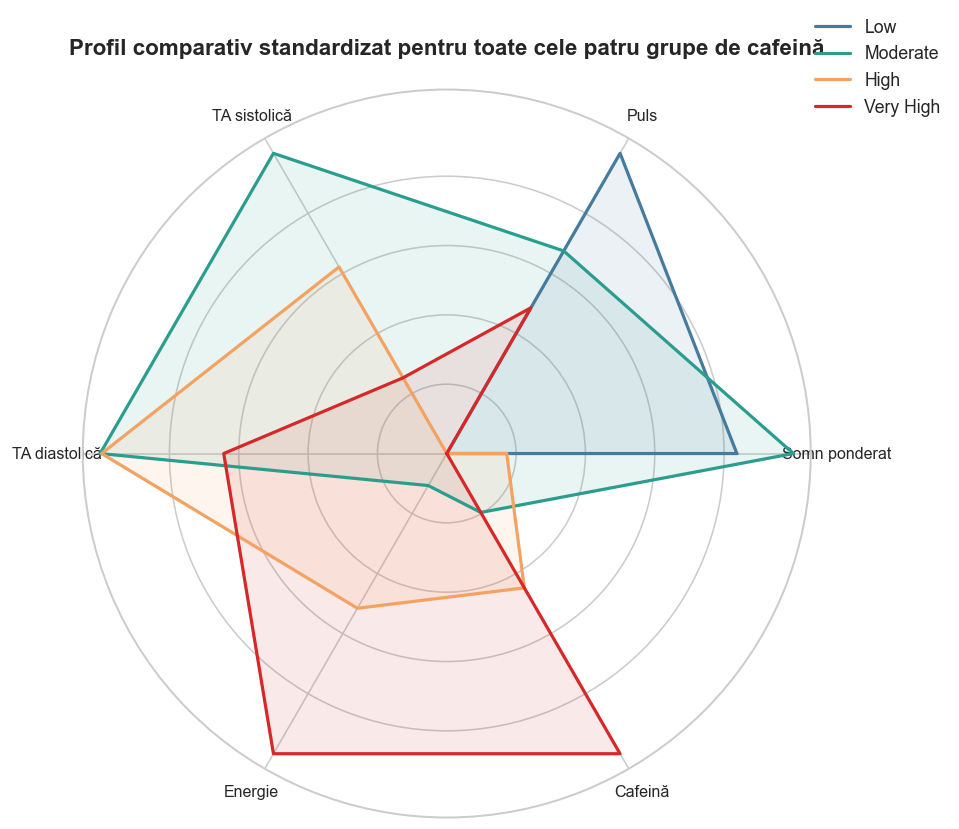

,avg_sleep_hours,pulse,avg_systolic_bp,avg_diastolic_bp,energy_kcal,caffeine_mg
caffeine_group,,,,,,
Low,7.84,72.47,125.08,71.74,"1,970.37",11.17
Moderate,7.88,71.77,127.58,73.30,"2,025.03",100.97
High,7.68,70.41,126.66,73.34,"2,233.59",216.06
Very High,7.64,71.50,125.68,72.73,"2,485.83",468.33


In [27]:
radar_features = [
    "avg_sleep_hours",
    "pulse",
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "energy_kcal",
    "caffeine_mg",
]
radar_groups = ["Low", "Moderate", "High", "Very High"]

radar_base_df = analysis_df[analysis_df["caffeine_group"].isin(radar_groups)][["caffeine_group"] + radar_features].dropna()

radar_scaled_values = StandardScaler().fit_transform(radar_base_df[radar_features])
radar_scaled_df = pd.DataFrame(radar_scaled_values, columns=radar_features, index=radar_base_df.index)
radar_scaled_df["caffeine_group"] = radar_base_df["caffeine_group"].values

radar_profile_z = (
    radar_scaled_df.groupby("caffeine_group", observed=False)[radar_features]
    .mean()
    .loc[radar_groups]
)

radar_profile_plot = radar_profile_z.copy()
for column in radar_profile_plot.columns:
    col_min = radar_profile_plot[column].min()
    col_max = radar_profile_plot[column].max()
    if np.isclose(col_min, col_max):
        radar_profile_plot[column] = 0.5
    else:
        radar_profile_plot[column] = (radar_profile_plot[column] - col_min) / (col_max - col_min)

radar_labels = {
    "avg_sleep_hours": "Somn ponderat",
    "pulse": "Puls",
    "avg_systolic_bp": "TA sistolică",
    "avg_diastolic_bp": "TA diastolică",
    "energy_kcal": "Energie",
    "caffeine_mg": "Cafeină",
}

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8.5, 8.5), subplot_kw={"polar": True})

for group in radar_groups:
    values = radar_profile_plot.loc[group].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=group, color=radar_palette[group])
    ax.fill(angles, values, alpha=0.10, color=radar_palette[group])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([radar_labels[col] for col in radar_features], fontsize=10)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels([])
ax.set_title("Profil comparativ standardizat pentru toate cele patru grupe de cafeină", pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.20, 1.12))
plt.tight_layout()
plt.show()

display(
    analysis_df[analysis_df["caffeine_group"].isin(radar_groups)]
    .groupby("caffeine_group", observed=False)[radar_features]
    .mean()
    .loc[radar_groups]
    .round(2)
)


Radar chart-ul trebuie citit împreună cu graficele și tabelele anterioare. El arată profiluri relative standardizate, deci accentul cade pe **diferențele dintre grupuri**, nu pe valorile absolute.

Ca instrument de prezentare, este util pentru că pune în aceeași imagine somnul, pulsul, tensiunea, energia și cafeina. Ca instrument analitic, rămâne doar un rezumat: interpretările importante vin tot din distribuții, corelații și comparațiile numerice.


In [28]:
top_missing_row = missing_reports.sort_values("missing_pct", ascending=False).iloc[0]
top_missing_label = f"{top_missing_row['table']} - {top_missing_row['column']}"

checkpoint1_md = f"""
### Concluzii pentru Checkpoint 1

- Lotul final conține **{len(analysis_df):,} participanți adulți** și reprezintă subsetul pentru care avem informații compatibile în toate sursele necesare.
- Cele mai multe lipsuri apar în **{top_missing_label}** (**{top_missing_row['missing_pct']:.2f}%**), ceea ce arată că problemele de completitudine se concentrează mai ales în măsurători repetate, nu neapărat în variabilele centrale.
- Legătura `caffeine_mg` - `pulse` este **slabă** și rămâne modestă atât în Pearson, cât și în Spearman.
- Legătura `caffeine_mg` - `avg_sleep_hours` este tot **slabă**, dar ușor mai vizibilă decât cea cu pulsul.
- Relația `age` - `avg_systolic_bp` apare mai clar și este un reper bun pentru faptul că setul de date conține semnal biologic plauzibil.
- Toată această etapă rămâne exploratorie: sugerează tipare, dar nu justifică afirmații cauzale.

### Repere rapide pentru prezentare
- am pornit din patru tabele NHANES și am păstrat doar variabilele utile pentru obiectivul proiectului;
- am tratat valorile imposibile ca lipsă și am păstrat valorile extreme plauzibile;
- lotul final este coerent, dar selectiv;
- cafeina nu oferă singură un semnal puternic pentru puls;
- somnul pare doar ușor mai sensibil la diferențele de aport de cafeină.
"""

display(Markdown(checkpoint1_md))



### Concluzii pentru Checkpoint 1

- Lotul final conține **4,824 participanți adulți** și reprezintă subsetul pentru care avem informații compatibile în toate sursele necesare.
- Cele mai multe lipsuri apar în **bp - diastolic_4** (**93.75%**), ceea ce arată că problemele de completitudine se concentrează mai ales în măsurători repetate, nu neapărat în variabilele centrale.
- Legătura `caffeine_mg` - `pulse` este **slabă** și rămâne modestă atât în Pearson, cât și în Spearman.
- Legătura `caffeine_mg` - `avg_sleep_hours` este tot **slabă**, dar ușor mai vizibilă decât cea cu pulsul.
- Relația `age` - `avg_systolic_bp` apare mai clar și este un reper bun pentru faptul că setul de date conține semnal biologic plauzibil.
- Toată această etapă rămâne exploratorie: sugerează tipare, dar nu justifică afirmații cauzale.

### Repere rapide pentru prezentare
- am pornit din patru tabele NHANES și am păstrat doar variabilele utile pentru obiectivul proiectului;
- am tratat valorile imposibile ca lipsă și am păstrat valorile extreme plauzibile;
- lotul final este coerent, dar selectiv;
- cafeina nu oferă singură un semnal puternic pentru puls;
- somnul pare doar ușor mai sensibil la diferențele de aport de cafeină.


## Tranziție spre Checkpoint 2

Analiza exploratorie sugerează deja direcția modelării: relațiile există, dar nu par suficient de puternice încât să presupunem din start performanțe predictive mari. Tocmai de aceea merită să trecem la două întrebări mai precise:

- **Regresia**: putem aproxima `pulse` din variabilele disponibile?
- **Clasificarea**: putem identifica un `high_pulse` folosind același tip de informații?

Împărțirea pe membri rămâne aceeași, dar trecerea este acum firească: modelarea nu apare din senin, ci ca o verificare a ceea ce am văzut deja în EDA.


## Checkpoint 2: Modelarea datelor

În continuarea analizei exploratorii, folosim același `analysis_df` construit în Checkpoint 1. Nu urmărim modele clinice și nici nu forțăm ideea de predicție puternică; vrem să vedem cât semnal explicativ sau predictiv rămâne după toți pașii anteriori de selecție și curățare.

Abordăm două probleme complementare:
- regresie pentru `pulse`, adică o țintă continuă;
- clasificare pentru `high_pulse`, adică o țintă binară dezechilibrată.


### Partea 1 - Regresie pentru `pulse`

Secțiunea pregătită de **Roibu Radu** urmărește dacă pulsul poate fi aproximat din variabilele pe care le-am considerat relevante în EDA: cafeină, aport energetic, vârstă, gen și somn mediu ponderat.

Păstrăm mai multe modele și adăugăm un baseline explicit (`DummyRegressor`) pentru a evita concluzii optimiste. Dacă modelele complexe nu depășesc clar baseline-ul, concluzia corectă este că semnalul predictiv rămâne limitat.


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

feature_columns = ["caffeine_mg", "energy_kcal", "age", "gender", "avg_sleep_hours"]
numeric_features = ["caffeine_mg", "energy_kcal", "age", "avg_sleep_hours"]
categorical_features = ["gender"]
feature_display_names = {
    "caffeine_mg": "Cafeină (mg)",
    "energy_kcal": "Energie (kcal)",
    "age": "Vârstă (ani)",
    "avg_sleep_hours": "Somn mediu ponderat (ore)",
}
category_value_labels = {
    "Female": "feminin",
    "Male": "masculin",
    "Unknown": "necunoscut",
}


def build_preprocessor(scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


def humanize_category_value(value):
    return category_value_labels.get(value, str(value).replace("_", " ").lower())


def clean_feature_name(raw_name, encoder=None):
    cleaned_name = raw_name.replace("num__", "").replace("cat__", "")

    if cleaned_name.startswith("gender_"):
        level = cleaned_name.split("_", 1)[1]
        label = f"Gen: {humanize_category_value(level)}"
        if encoder is not None and getattr(encoder, "drop", None) == "if_binary":
            reference_levels = [cat for cat in encoder.categories_[0] if str(cat) != level]
            if reference_levels:
                return f"{label} (față de {humanize_category_value(reference_levels[0])})"
        return label

    return feature_display_names.get(cleaned_name, cleaned_name.replace("_", " ").title())


def get_clean_feature_names(preprocessor):
    encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    raw_feature_names = preprocessor.get_feature_names_out()
    clean_feature_names = [
        clean_feature_name(name, encoder=encoder)
        for name in raw_feature_names
    ]
    return raw_feature_names, clean_feature_names


reg_df = analysis_df[feature_columns + ["pulse"]].copy()
reg_df = reg_df.dropna(subset=["pulse", "caffeine_mg", "energy_kcal", "age"])

print(f"Shape dataset pentru regresie: {reg_df.shape}")

X_reg = reg_df[feature_columns]
y_reg = reg_df["pulse"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

regression_models = {
    "Dummy Regressor": Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("model", DummyRegressor(strategy="mean")),
    ]),
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest Regressor": Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            min_samples_leaf=3,
            n_jobs=1
        )),
    ]),
}

regression_cv = KFold(n_splits=5, shuffle=True, random_state=42)
regression_scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

fitted_regression_models = {}
regression_predictions = {}
regression_rows = []

for model_name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)
    cv_scores = cross_validate(
        model,
        X_reg,
        y_reg,
        cv=regression_cv,
        scoring=regression_scoring,
        n_jobs=None,
    )

    fitted_regression_models[model_name] = model
    regression_predictions[model_name] = y_pred
    regression_rows.append({
        "model": model_name,
        "MAE_test": mean_absolute_error(y_test_reg, y_pred),
        "RMSE_test": np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        "R2_test": r2_score(y_test_reg, y_pred),
        "MAE_cv_mean": -cv_scores["test_MAE"].mean(),
        "RMSE_cv_mean": -cv_scores["test_RMSE"].mean(),
        "R2_cv_mean": cv_scores["test_R2"].mean(),
    })

regression_results = (
    pd.DataFrame(regression_rows)
    .sort_values(["RMSE_test", "MAE_test", "R2_test"], ascending=[True, True, False])
    .reset_index(drop=True)
)

best_regression_model_name = regression_results.iloc[0]["model"]
best_regression_model = fitted_regression_models[best_regression_model_name]
best_regression_pred = regression_predictions[best_regression_model_name]
residuals_best_regression = y_test_reg - best_regression_pred

regression_interpretable_model_name = (
    best_regression_model_name
    if best_regression_model_name != "Dummy Regressor"
    else regression_results.loc[regression_results["model"] != "Dummy Regressor", "model"].iloc[0]
)
regression_interpretable_model = fitted_regression_models[regression_interpretable_model_name]

regression_results_display = regression_results.copy()
for metric_col in ["MAE_test", "RMSE_test", "R2_test", "MAE_cv_mean", "RMSE_cv_mean", "R2_cv_mean"]:
    regression_results_display[metric_col] = regression_results_display[metric_col].map(lambda x: f"{x:.4f}")

display(regression_results_display)


Shape dataset pentru regresie: (4824, 6)


,model,MAE_test,RMSE_test,R2_test,MAE_cv_mean,RMSE_cv_mean,R2_cv_mean
0,Linear Regression,9.0817,11.2887,0.0514,8.9309,11.3414,0.0408
1,Ridge Regression,9.0817,11.2887,0.0514,8.9308,11.3414,0.0408
2,Random Forest Regressor,9.2400,11.4638,0.0218,9.2560,11.7566,-0.0307
3,Dummy Regressor,9.3744,11.5907,-0.0000,9.1401,11.5811,-0.0002


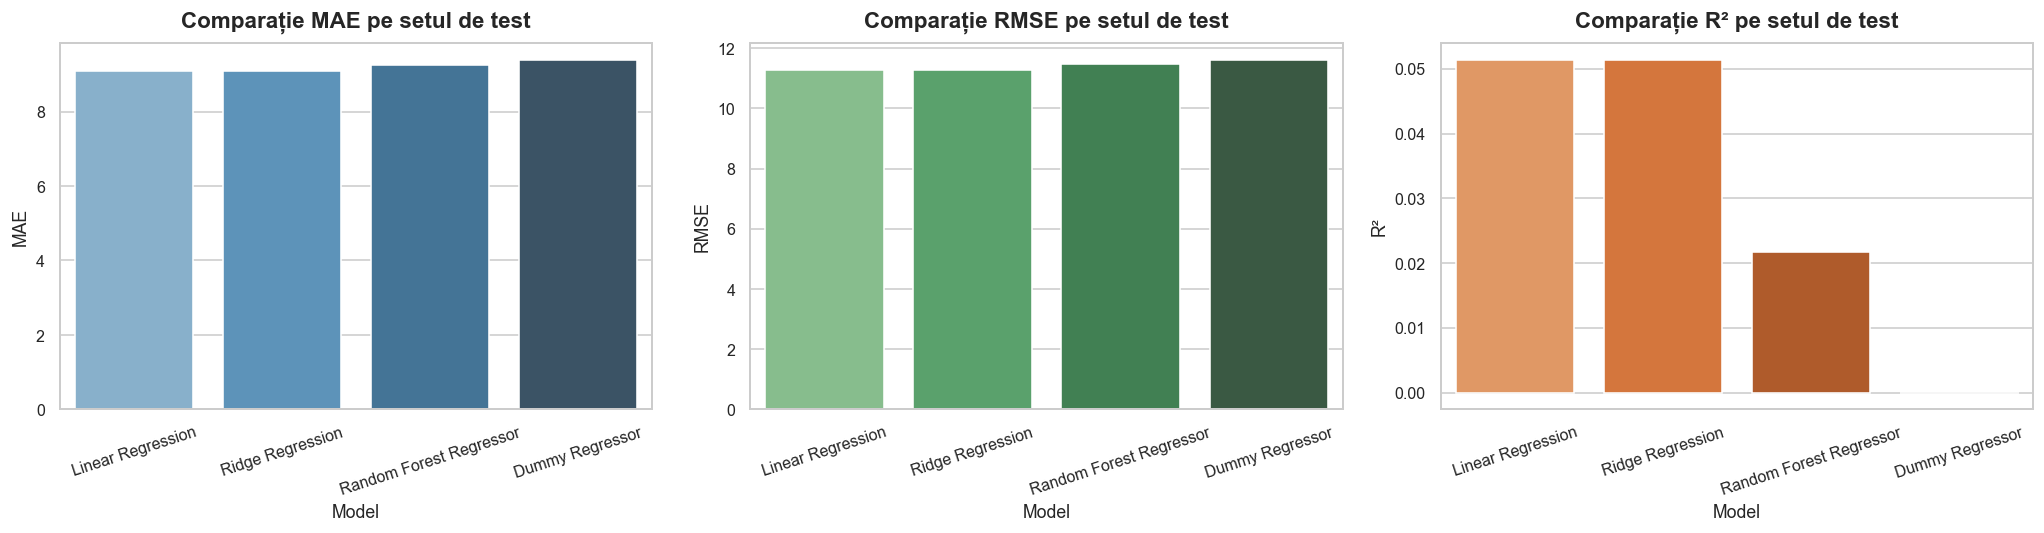

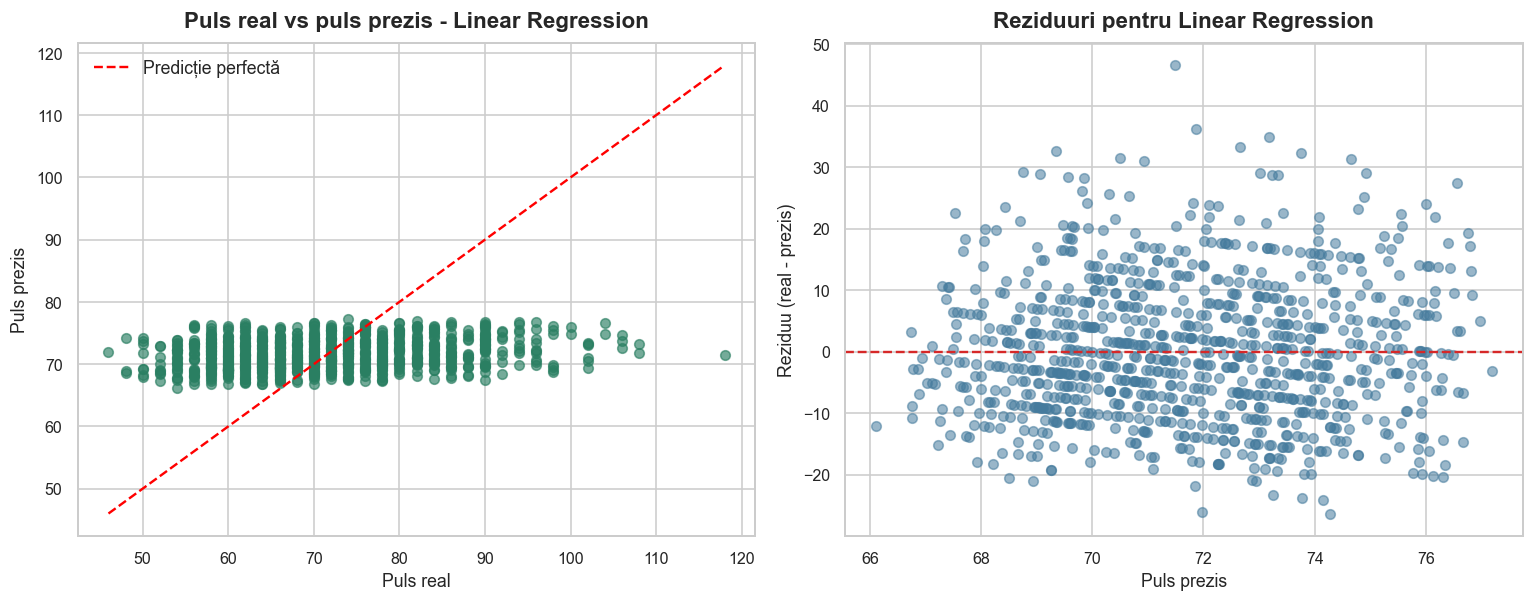

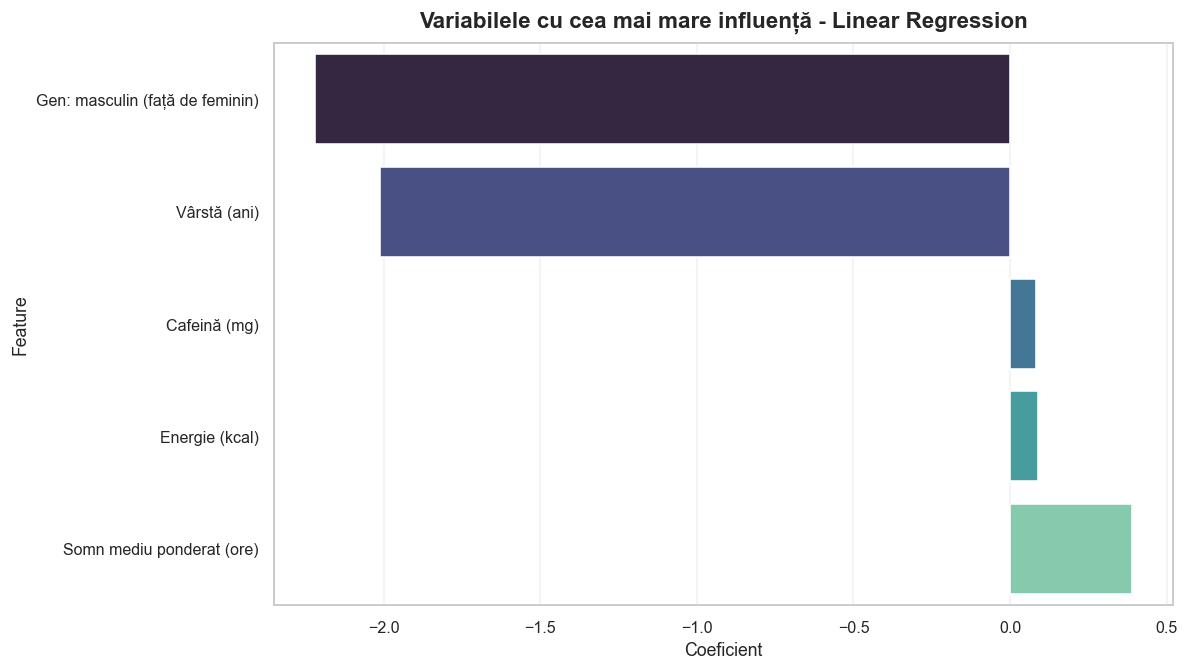

,feature,coefficient,abs_value
4,Gen: masculin (față de feminin),-2.22,2.22
2,Vârstă (ani),-2.01,2.01
3,Somn mediu ponderat (ore),0.39,0.39
1,Energie (kcal),0.09,0.09
0,Cafeină (mg),0.08,0.08


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.barplot(data=regression_results, x="model", y="MAE_test", ax=axes[0], palette="Blues_d")
axes[0].set_title("Comparație MAE pe setul de test")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=18)

sns.barplot(data=regression_results, x="model", y="RMSE_test", ax=axes[1], palette="Greens_d")
axes[1].set_title("Comparație RMSE pe setul de test")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=18)

sns.barplot(data=regression_results, x="model", y="R2_test", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Comparație R² pe setul de test")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=18)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

axes[0].scatter(y_test_reg, best_regression_pred, alpha=0.65, color="#2a7f62")
axes[0].plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="red",
    linestyle="--",
    label="Predicție perfectă"
)
axes[0].set_title(f"Puls real vs puls prezis - {best_regression_model_name}")
axes[0].set_xlabel("Puls real")
axes[0].set_ylabel("Puls prezis")
axes[0].legend()

axes[1].scatter(best_regression_pred, residuals_best_regression, alpha=0.55, color="#457b9d")
axes[1].axhline(0, color="#d62828", linestyle="--", linewidth=1.5)
axes[1].set_title(f"Reziduuri pentru {best_regression_model_name}")
axes[1].set_xlabel("Puls prezis")
axes[1].set_ylabel("Reziduu (real - prezis)")

plt.tight_layout()
plt.show()

regression_raw_feature_names, regression_clean_feature_names = get_clean_feature_names(
    regression_interpretable_model.named_steps["preprocessor"]
)
if regression_interpretable_model_name in ["Linear Regression", "Ridge Regression"]:
    regression_feature_values = regression_interpretable_model.named_steps["model"].coef_
    value_column = "coefficient"
    x_label = "Coeficient"
else:
    regression_feature_values = regression_interpretable_model.named_steps["model"].feature_importances_
    value_column = "importance"
    x_label = "Importanță"

best_regression_importance_df = pd.DataFrame({
    "raw_feature": regression_raw_feature_names,
    "feature": regression_clean_feature_names,
    value_column: regression_feature_values,
})
best_regression_importance_df["abs_value"] = best_regression_importance_df[value_column].abs()
best_regression_importance_df = best_regression_importance_df.sort_values("abs_value", ascending=False)

feature_plot_df = best_regression_importance_df.head(10).sort_values(value_column)

fig, ax = plt.subplots(figsize=(10.5, 6.0))
sns.barplot(data=feature_plot_df, x=value_column, y="feature", palette="mako", ax=ax)
ax.set_title(f"Variabilele cu cea mai mare influență - {regression_interpretable_model_name}")
ax.set_xlabel(x_label)
ax.set_ylabel("Feature")
ax.tick_params(axis="y", labelsize=10)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(best_regression_importance_df[["feature", value_column, "abs_value"]].head(10))


### Interpretare scurtă - Partea 1

Regresia răspunde la întrebarea: **cât din variația pulsului poate fi surprinsă de variabilele disponibile?** De aceea citim împreună `MAE`, `RMSE` și `R²`, iar dacă este nevoie comparăm și cu baseline-ul.

În plus, folosim două tipuri de verificări:
- performanța pe setul de test, ca estimare directă pe un split separat;
- cross-validation simplă, pentru a vedea dacă ordinea modelelor rămâne stabilă.

Dacă `R²` rămâne mic și reziduurile sunt larg dispersate, interpretarea matură este că modelul explică doar o parte redusă din variația pulsului.


### Partea 2 - Clasificare pentru `high_pulse`

Secțiunea pregătită de **Ionescu Corina** schimbă întrebarea: nu mai prezicem o valoare continuă, ci încercăm să separăm participanții cu `high_pulse = 1` de cei cu `0`.

Pentru această problemă este esențial să păstrăm un baseline (`DummyClassifier`) și să interpretăm rezultatele în contextul dezechilibrului de clasă. Accuracy-ul singur poate arăta înșelător de bine atunci când clasa pozitivă este rară, de aceea urmărim și `Precision`, `Recall`, `F1`, `ROC-AUC` și `Average Precision`.


Shape dataset pentru clasificare: (4824, 6)


,high_pulse,count,proportion,label
0,0,4556,0.94,0 = puls ne-ridicat
1,1,268,0.06,1 = puls ridicat


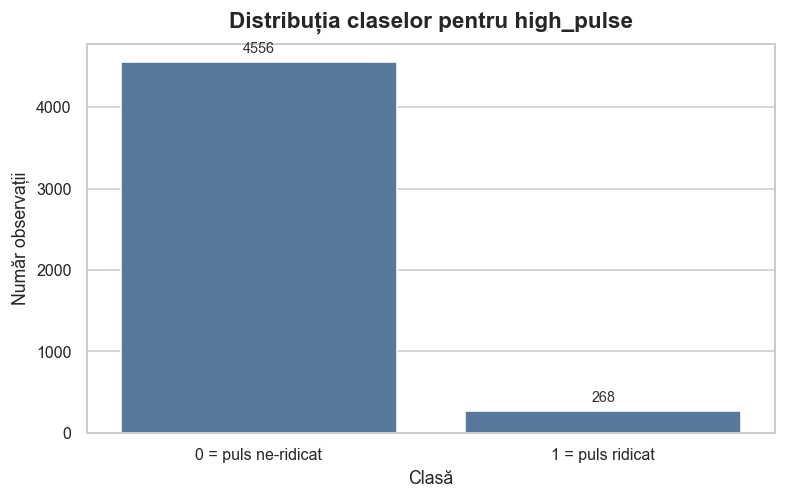

,model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Logistic Regression,0.5461,0.0714,0.5926,0.1275,0.5738,0.0661
1,Random Forest,0.9430,0.0000,0.0000,0.0000,0.5809,0.0720
2,Dummy Classifier,0.9440,0.0000,0.0000,0.0000,0.5000,0.0560


In [31]:
clf_df = analysis_df[feature_columns + ["high_pulse"]].copy()
clf_df = clf_df.dropna(subset=["caffeine_mg", "energy_kcal", "age", "high_pulse"])

print(f"Shape dataset pentru clasificare: {clf_df.shape}")

class_distribution_df = (
    clf_df["high_pulse"]
    .value_counts()
    .sort_index()
    .rename_axis("high_pulse")
    .reset_index(name="count")
)
class_distribution_df["proportion"] = (class_distribution_df["count"] / len(clf_df)).round(4)
class_distribution_df["label"] = class_distribution_df["high_pulse"].map({
    0: "0 = puls ne-ridicat",
    1: "1 = puls ridicat",
})

display(class_distribution_df)

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=class_distribution_df, x="label", y="count", color="#4c78a8")
plt.title("Distribuția claselor pentru high_pulse")
plt.xlabel("Clasă")
plt.ylabel("Număr observații")
annotate_bar_values(ax, orientation="v", fmt="{:.0f}")
plt.tight_layout()
plt.show()

X_clf = clf_df[feature_columns]
y_clf = clf_df["high_pulse"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

classification_primary_metric = "F1"
classification_tie_breakers = ["Average Precision", "ROC-AUC", "Recall"]

classification_models = {
    "Dummy Classifier": Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=True)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=3,
            n_jobs=1
        )),
    ]),
}

fitted_classification_models = {}
classification_predictions = {}
classification_probabilities = {}
classification_rows = []

for model_name, model in classification_models.items():
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    y_score = model.predict_proba(X_test_clf)[:, 1]
    fitted_classification_models[model_name] = model
    classification_predictions[model_name] = y_pred
    classification_probabilities[model_name] = y_score
    classification_rows.append({
        "model": model_name,
        "Accuracy": accuracy_score(y_test_clf, y_pred),
        "Precision": precision_score(y_test_clf, y_pred, zero_division=0),
        "Recall": recall_score(y_test_clf, y_pred, zero_division=0),
        "F1": f1_score(y_test_clf, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_clf, y_score),
        "Average Precision": average_precision_score(y_test_clf, y_score),
    })

classification_results = (
    pd.DataFrame(classification_rows)
    .sort_values(
        [classification_primary_metric] + classification_tie_breakers,
        ascending=[False] * (1 + len(classification_tie_breakers))
    )
    .reset_index(drop=True)
)

best_classification_model_name = classification_results.iloc[0]["model"]
best_classification_model = fitted_classification_models[best_classification_model_name]

classification_results_display = classification_results.copy()
for metric_col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Average Precision"]:
    classification_results_display[metric_col] = classification_results_display[metric_col].map(lambda x: f"{x:.4f}")

display(classification_results_display)


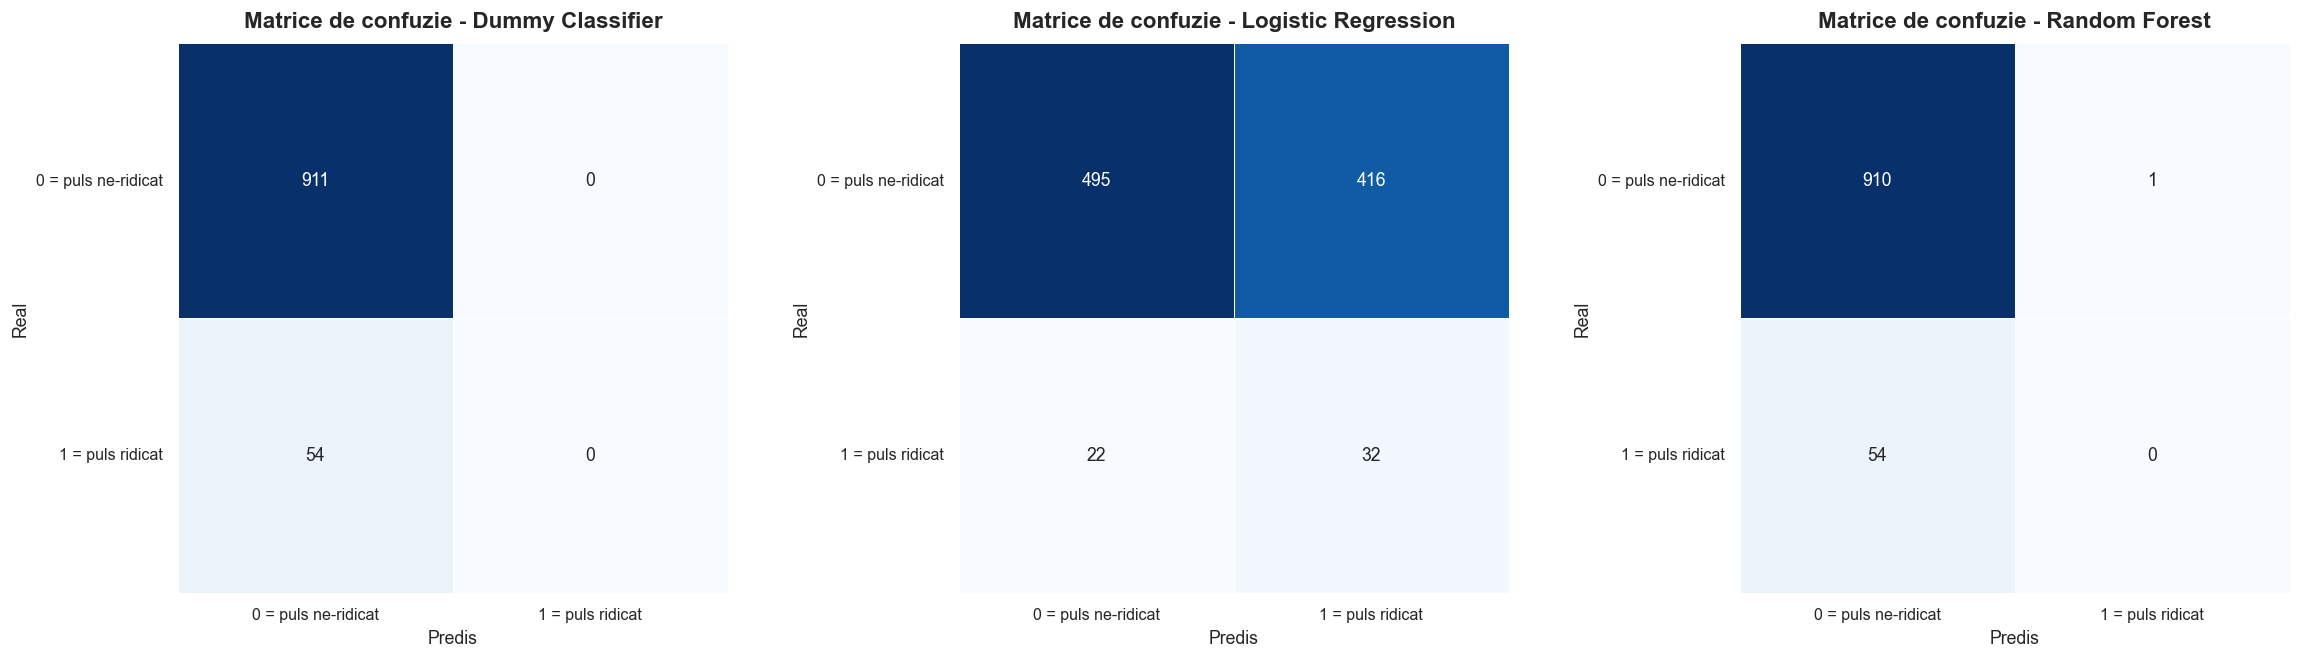

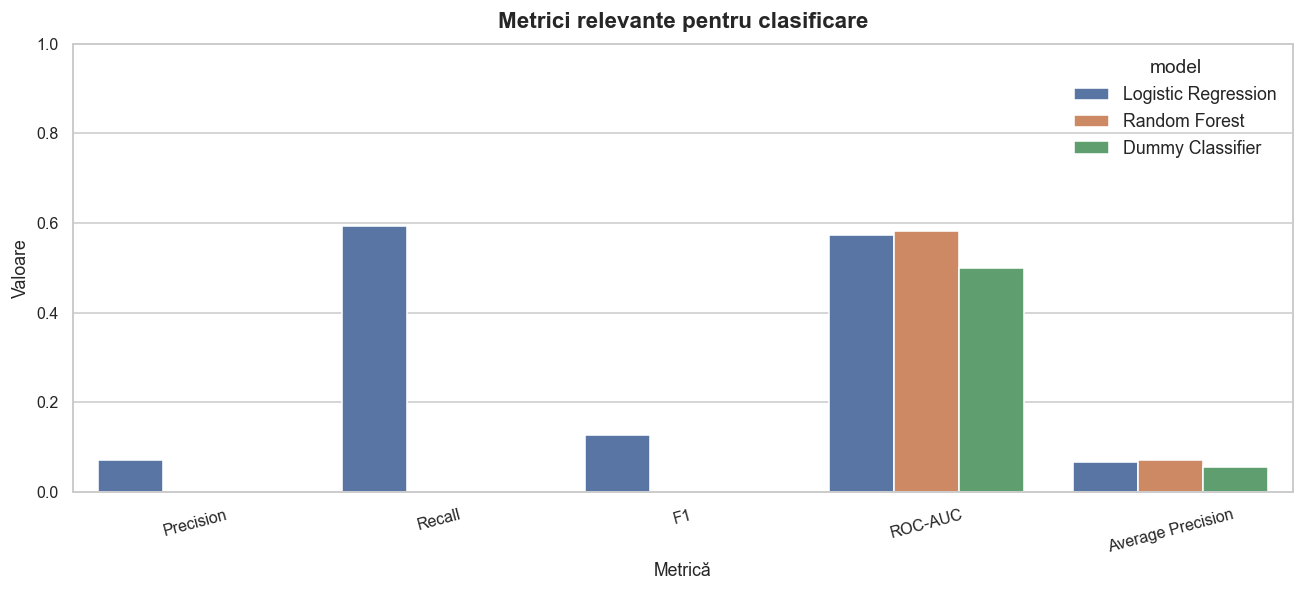

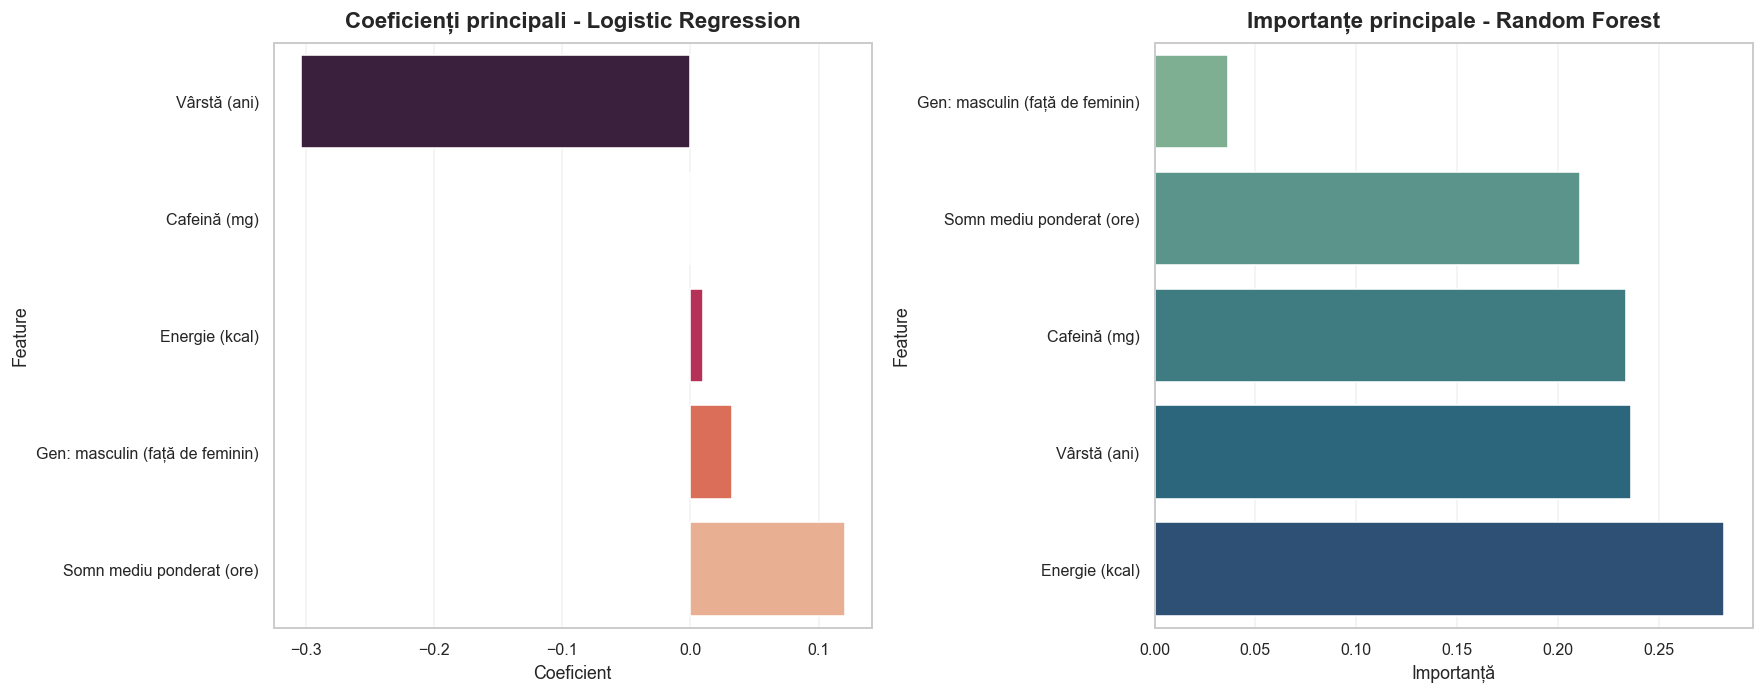

Coeficienți principali pentru Logistic Regression:


,feature,coefficient,abs_coefficient
2,Vârstă (ani),-0.30,0.30
3,Somn mediu ponderat (ore),0.12,0.12
4,Gen: masculin (față de feminin),0.03,0.03
1,Energie (kcal),0.01,0.01
0,Cafeină (mg),-0.00,0.00


Importanțe principale pentru Random Forest:


,feature,importance
1,Energie (kcal),0.28
2,Vârstă (ani),0.24
0,Cafeină (mg),0.23
3,Somn mediu ponderat (ore),0.21
4,Gen: masculin (față de feminin),0.04


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20.5, 6.0))
class_axis_labels = ["0 = puls ne-ridicat", "1 = puls ridicat"]

for ax, model_name in zip(axes, classification_models.keys()):
    cm = confusion_matrix(y_test_clf, classification_predictions[model_name])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=class_axis_labels,
        yticklabels=class_axis_labels,
        cbar=False,
        square=True,
        linewidths=0.5,
        annot_kws={"fontsize": 11},
    )
    ax.set_title(f"Matrice de confuzie - {model_name}")
    ax.set_xlabel("Predis")
    ax.set_ylabel("Real")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout(pad=1.4, w_pad=2.2)
plt.show()

classification_metrics_plot = classification_results.melt(
    id_vars="model",
    value_vars=["Precision", "Recall", "F1", "ROC-AUC", "Average Precision"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(11.5, 5.3))
sns.barplot(data=classification_metrics_plot, x="metric", y="value", hue="model")
plt.title("Metrici relevante pentru clasificare")
plt.xlabel("Metrică")
plt.ylabel("Valoare")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

logreg_model = fitted_classification_models["Logistic Regression"]
logreg_raw_feature_names, logreg_clean_feature_names = get_clean_feature_names(
    logreg_model.named_steps["preprocessor"]
)
logreg_coef_df = pd.DataFrame({
    "raw_feature": logreg_raw_feature_names,
    "feature": logreg_clean_feature_names,
    "coefficient": logreg_model.named_steps["model"].coef_[0],
})
logreg_coef_df["abs_coefficient"] = logreg_coef_df["coefficient"].abs()
logreg_coef_df = logreg_coef_df.sort_values("abs_coefficient", ascending=False)

rf_model = fitted_classification_models["Random Forest"]
rf_raw_feature_names, rf_clean_feature_names = get_clean_feature_names(
    rf_model.named_steps["preprocessor"]
)
rf_importance_df = pd.DataFrame({
    "raw_feature": rf_raw_feature_names,
    "feature": rf_clean_feature_names,
    "importance": rf_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.2))

sns.barplot(
    data=logreg_coef_df.head(10).sort_values("coefficient"),
    x="coefficient",
    y="feature",
    palette="rocket",
    ax=axes[0],
)
axes[0].set_title("Coeficienți principali - Logistic Regression")
axes[0].set_xlabel("Coeficient")
axes[0].set_ylabel("Feature")
axes[0].tick_params(axis="y", labelsize=10)
axes[0].grid(axis="x", alpha=0.25)

sns.barplot(
    data=rf_importance_df.head(10).sort_values("importance"),
    x="importance",
    y="feature",
    palette="crest",
    ax=axes[1],
)
axes[1].set_title("Importanțe principale - Random Forest")
axes[1].set_xlabel("Importanță")
axes[1].set_ylabel("Feature")
axes[1].tick_params(axis="y", labelsize=10)
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

print("Coeficienți principali pentru Logistic Regression:")
display(logreg_coef_df[["feature", "coefficient", "abs_coefficient"]].head(10))

print("Importanțe principale pentru Random Forest:")
display(rf_importance_df[["feature", "importance"]].head(10))


### Interpretare scurtă - Partea 2

În clasificare, accentul cade pe echilibrul dintre identificarea cazurilor pozitive și numărul de erori pe care modelul le produce. Matricea de confuzie arată concret unde apar aceste greșeli, iar `Average Precision` completează `ROC-AUC` într-un context cu clasă pozitivă rară.

Modelul principal este selectat în primul rând după `F1`, iar `Average Precision`, `ROC-AUC` și `Recall` sunt folosite ca metrici de sprijin și departajare. `Accuracy` singur nu este suficient, tocmai pentru că un baseline care prezice predominant clasa negativă poate părea artificial „bun”.

Dacă un model obține accuracy mare, dar rămâne aproape de baseline la `F1` sau `Average Precision`, nu putem vorbi despre o clasificare puternică. Concluzia corectă este că problema rămâne dificilă cu predictorii disponibili.


### Partea 3 - Evaluare comună și interpretare

Secțiunea pregătită de **Lazar Alessia** adună rezultatele celor două direcții fără a le confunda. Regresia și clasificarea răspund la întrebări diferite, deci trebuie judecate separat și apoi sintetizate într-o concluzie comună, onestă și ușor de prezentat.

#### Limitări ale analizei
- lucrăm cu date observaționale, deci nu putem susține relații cauzale;
- variabilele alimentare și consumul de cafeină provin din raportare individuală;
- somnul este tot auto-raportat, deci poate include erori de estimare;
- lotul final este influențat de `inner join` și de filtrele aplicate, ceea ce poate introduce bias de selecție;
- nu există validare externă pe un alt set de date, iar rezultatele descriu lotul final analizat și trebuie generalizate cu prudență;
- modelele au scop exploratoriu și educațional, nu clinic.


In [33]:
best_regression_row = regression_results.iloc[0]
dummy_regression_row = regression_results.loc[regression_results["model"] == "Dummy Regressor"].iloc[0]
best_classification_row = classification_results.iloc[0]
dummy_classification_row = classification_results.loc[classification_results["model"] == "Dummy Classifier"].iloc[0]
positive_class_rate = float(class_distribution_df.loc[class_distribution_df["high_pulse"] == 1, "proportion"].iloc[0])

linear_regression_row = regression_results.loc[regression_results["model"] == "Linear Regression"].iloc[0]
ridge_regression_row = regression_results.loc[regression_results["model"] == "Ridge Regression"].iloc[0]
best_average_precision_row = (
    classification_results
    .sort_values(["Average Precision", "ROC-AUC", "F1", "Recall"], ascending=[False, False, False, False])
    .iloc[0]
)

regression_rmse_gain = float(dummy_regression_row["RMSE_test"] - best_regression_row["RMSE_test"])
classification_ap_gain = float(best_classification_row["Average Precision"] - dummy_classification_row["Average Precision"])

if best_regression_row["R2_test"] < 0.10:
    regression_interpretation = (
        f"Cea mai bună regresie este **{best_regression_row['model']}**, dar semnalul predictiv rămâne slab "
        f"(R² test = {best_regression_row['R2_test']:.3f}, RMSE test = {best_regression_row['RMSE_test']:.3f}). "
        f"Față de baseline, câștigul de RMSE este de aproximativ **{regression_rmse_gain:.3f}**."
    )
else:
    regression_interpretation = (
        f"Cea mai bună regresie este **{best_regression_row['model']}**, cu performanță moderată "
        f"(R² test = {best_regression_row['R2_test']:.3f}, RMSE test = {best_regression_row['RMSE_test']:.3f})."
    )

if (
    abs(linear_regression_row["MAE_test"] - ridge_regression_row["MAE_test"]) < 0.01
    and abs(linear_regression_row["RMSE_test"] - ridge_regression_row["RMSE_test"]) < 0.01
    and abs(linear_regression_row["R2_test"] - ridge_regression_row["R2_test"]) < 0.01
):
    regression_selection_note = (
        "Linear Regression și Ridge Regression au performanțe aproape identice; "
        "am păstrat Linear Regression ca model de referință pentru simplitate și interpretabilitate."
    )
else:
    regression_selection_note = (
        f"Linear Regression și Ridge Regression rămân foarte apropiate, dar tabelul cu mai multe zecimale "
        f"arată diferențe mici între ele (de exemplu RMSE test: {linear_regression_row['RMSE_test']:.4f} "
        f"vs {ridge_regression_row['RMSE_test']:.4f})."
    )

classification_selection_note = (
    f"Modelul principal de clasificare este ales după **{classification_primary_metric}**, "
    "nu după accuracy, deoarece problema este dezechilibrată."
)

if best_average_precision_row["model"] != best_classification_row["model"]:
    average_precision_note = (
        f"Pe `F1`, modelul principal rămâne **{best_classification_row['model']}**, "
        f"dar **{best_average_precision_row['model']}** obține un `Average Precision` ușor mai bun "
        f"({best_average_precision_row['Average Precision']:.3f} vs {best_classification_row['Average Precision']:.3f})."
    )
else:
    average_precision_note = (
        f"Același model conduce și la `Average Precision` = **{best_classification_row['Average Precision']:.3f}**, "
        "deci ierarhia rămâne stabilă și pe această metrică."
    )

if best_classification_row["F1"] < 0.25 or classification_ap_gain < 0.05:
    classification_interpretation = (
        f"Clasificarea rămâne dificilă: cel mai bun model, **{best_classification_row['model']}**, "
        f"obține F1 = {best_classification_row['F1']:.3f}, ROC-AUC = {best_classification_row['ROC-AUC']:.3f} "
        f"și Average Precision = {best_classification_row['Average Precision']:.3f}. "
        f"Îmbunătățirea față de baseline la Average Precision este de doar **{classification_ap_gain:.3f}**."
    )
else:
    classification_interpretation = (
        f"Cel mai bun clasificator este **{best_classification_row['model']}**, cu F1 = {best_classification_row['F1']:.3f}, "
        f"ROC-AUC = {best_classification_row['ROC-AUC']:.3f} și Average Precision = {best_classification_row['Average Precision']:.3f}."
    )

model_interpretation_md = f"""
### Concluzii pentru Checkpoint 2

- {regression_interpretation}
- {regression_selection_note}
- Pentru `high_pulse`, clasa pozitivă reprezintă aproximativ **{positive_class_rate * 100:.2f}%** din date, deci problema este clar dezechilibrată.
- {classification_selection_note}
- Baseline-ul de clasificare are accuracy mare tocmai pentru că majoritatea cazurilor sunt negative; de aceea accuracy-ul nu este suficient singur.
- {classification_interpretation}
- {average_precision_note}
- Concluzia comună este coerentă cu EDA: modelele au valoare exploratorie și didactică, dar nu susțin ideea unui semnal predictiv puternic.
"""

display(Markdown(model_interpretation_md))



### Concluzii pentru Checkpoint 2

- Cea mai bună regresie este **Linear Regression**, dar semnalul predictiv rămâne slab (R² test = 0.051, RMSE test = 11.289). Față de baseline, câștigul de RMSE este de aproximativ **0.302**.
- Linear Regression și Ridge Regression au performanțe aproape identice; am păstrat Linear Regression ca model de referință pentru simplitate și interpretabilitate.
- Pentru `high_pulse`, clasa pozitivă reprezintă aproximativ **5.56%** din date, deci problema este clar dezechilibrată.
- Modelul principal de clasificare este ales după **F1**, nu după accuracy, deoarece problema este dezechilibrată.
- Baseline-ul de clasificare are accuracy mare tocmai pentru că majoritatea cazurilor sunt negative; de aceea accuracy-ul nu este suficient singur.
- Clasificarea rămâne dificilă: cel mai bun model, **Logistic Regression**, obține F1 = 0.127, ROC-AUC = 0.574 și Average Precision = 0.066. Îmbunătățirea față de baseline la Average Precision este de doar **0.010**.
- Pe `F1`, modelul principal rămâne **Logistic Regression**, dar **Random Forest** obține un `Average Precision` ușor mai bun (0.072 vs 0.066).
- Concluzia comună este coerentă cu EDA: modelele au valoare exploratorie și didactică, dar nu susțin ideea unui semnal predictiv puternic.


In [34]:
final_conclusion_md = f"""
## Concluzie finală

Am pornit de la patru surse NHANES și am construit un lot final de **{len(analysis_df):,} participanți adulți** pentru care am putut urmări, în mod coerent, cafeina, energia, somnul, pulsul și demografia. Curățarea a tratat valorile imposibile ca lipsă, a păstrat valorile extreme plauzibile și a făcut explicit costul metodologic al `inner join`-ului: lotul final este mai coerent, dar și mai selectiv.

În analiza exploratorie, relațiile dintre `caffeine_mg`, `pulse` și `avg_sleep_hours` au rămas slabe. Pentru somn apare cel mult un semnal modest, iar pentru puls legătura este și mai redusă. În schimb, relații mai clasice, precum cea dintre `age` și `avg_systolic_bp`, apar mai clar și susțin ideea că setul de date conține semnal real, dar nu neapărat pe direcția pe care o anticipam inițial.

Modelele din Checkpoint 2 spun aceeași poveste într-o formă predictivă: regresia pentru `pulse` surprinde doar limitat variația țintei, iar clasificarea pentru `high_pulse` rămâne dificilă din cauza semnalului modest și a dezechilibrului de clasă. Valoarea proiectului nu scade din acest motiv; dimpotrivă, concluzia este mai credibilă tocmai pentru că nu forțează o relație puternică acolo unde datele nu o susțin.

### Mesaj pentru prezentare
- am construit responsabil lotul final, nu am tratat analiza ca pe o colecție de grafice;
- datele nu susțin o relație puternică și simplă între cafeină și puls;
- pentru somn apare cel mult un efect slab, vizibil mai ales descriptiv;
- vârsta și tensiunea sistolică oferă un contrast mai clar decât relațiile centrate pe cafeină;
- modelele au valoare în primul rând exploratorie și educațională, nu predictivă în sens clinic.

### Împărțirea pentru prezentare
- **Roibu Radu**: construirea lotului, variabilele derivate și partea de regresie pentru `pulse`;
- **Ionescu Corina**: definiția `high_pulse`, dezechilibrul de clasă și clasificarea;
- **Lazar Alessia**: sinteza finală, limitele și mesajul comun al proiectului.
"""

display(Markdown(final_conclusion_md))



## Concluzie finală

Am pornit de la patru surse NHANES și am construit un lot final de **4,824 participanți adulți** pentru care am putut urmări, în mod coerent, cafeina, energia, somnul, pulsul și demografia. Curățarea a tratat valorile imposibile ca lipsă, a păstrat valorile extreme plauzibile și a făcut explicit costul metodologic al `inner join`-ului: lotul final este mai coerent, dar și mai selectiv.

În analiza exploratorie, relațiile dintre `caffeine_mg`, `pulse` și `avg_sleep_hours` au rămas slabe. Pentru somn apare cel mult un semnal modest, iar pentru puls legătura este și mai redusă. În schimb, relații mai clasice, precum cea dintre `age` și `avg_systolic_bp`, apar mai clar și susțin ideea că setul de date conține semnal real, dar nu neapărat pe direcția pe care o anticipam inițial.

Modelele din Checkpoint 2 spun aceeași poveste într-o formă predictivă: regresia pentru `pulse` surprinde doar limitat variația țintei, iar clasificarea pentru `high_pulse` rămâne dificilă din cauza semnalului modest și a dezechilibrului de clasă. Valoarea proiectului nu scade din acest motiv; dimpotrivă, concluzia este mai credibilă tocmai pentru că nu forțează o relație puternică acolo unde datele nu o susțin.

### Mesaj pentru prezentare
- am construit responsabil lotul final, nu am tratat analiza ca pe o colecție de grafice;
- datele nu susțin o relație puternică și simplă între cafeină și puls;
- pentru somn apare cel mult un efect slab, vizibil mai ales descriptiv;
- vârsta și tensiunea sistolică oferă un contrast mai clar decât relațiile centrate pe cafeină;
- modelele au valoare în primul rând exploratorie și educațională, nu predictivă în sens clinic.

### Împărțirea pentru prezentare
- **Roibu Radu**: construirea lotului, variabilele derivate și partea de regresie pentru `pulse`;
- **Ionescu Corina**: definiția `high_pulse`, dezechilibrul de clasă și clasificarea;
- **Lazar Alessia**: sinteza finală, limitele și mesajul comun al proiectului.
